In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from rapidfuzz import fuzz #the core algorithm behind rapidfuzz is Levenshtein Distance which works on culculting the minimum number of operstion needed to convert one string into another 


# Dealing with the handling of different type of files supported by pandas! The goal is to achieve that user just give file name then all the things will be done by our logics

In [2]:
#this function is used to parse the file name and extract the extension from the file name 
def ExtensionHandler(filename):
    for i in range(len(filename)):
        if(filename[i]=="."):
            extension=""
            extension = filename[i:len(filename)]
        else:
            continue
    return extension.lower()


def FileLoader(filename):
    file_extension = ExtensionHandler(filename)

    common_file_readers={
        ".csv":pd.read_csv,
        '.txt': pd.read_table,
        '.tsv': pd.read_table,
        '.xlsx': pd.read_excel,
        '.xls': pd.read_excel,
        '.json': pd.read_json,
        '.parquet': pd.read_parquet,
        '.feather': pd.read_feather,
        '.xml': pd.read_xml,
        '.html': pd.read_html,
        '.pkl': pd.read_pickle
    }

    if file_extension not in common_file_readers:
        raise ValueError(f"Unsupported file type: {file_extension}")


    return common_file_readers[file_extension](filename)
    

# This is the logic of dealing with the null values in the data set, here our aim is to tell user about the exact column wise null value status for the entire dataset

In [3]:
def NullValuesScenario(null_analysis,df):
    if max(null_analysis.values) == 0:
        print("-------------------------------------------------------------------------")
        print("In your Dataset No Missing or Null Values")
        print("-------------------------------------------------------------------------")
        print(null_analysis)
        print("-------------------------------------------------------------------------")
    else:
        null_attributes=[]
        print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")
        print("There is some missing values in your Dataset:")
        print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")
        for i in range(len(null_analysis.values)):
            if null_analysis.values[i]>0:
                null_count = null_analysis.values[i]
                column_name = null_analysis.index[i]
                percentage = (null_count / len(df)) * 100

                print(f"=> There are *** {null_count} *** Null Values in the *** {column_name} *** Attribute")
                print(f"   =>Missing Percentage: {percentage:.2f}%\n")

                null_attributes.append(column_name)

            else:
                continue
        null_value_handled_df = NullValueHandler(df,null_attributes)
        return null_value_handled_df
    return df

# now, before heading towards futher visualisation or operational insights if there were null values so we have to handle them according to the user needs

In [4]:
def NullValueHandler(df, null_attributes):

     print("x" * 110)
     print("There are multiple ways to handle Null Values.")
     print("Below are the methods and their ideal use cases:")
     print("x" * 110)
     
     while True:
         print("\nMETHODS TO HANDLE NULL VALUES:\n")

         print("1️ Drop all rows that contain any null value")
         print("   => Use when null values are very few (<5%) and dataset is large.")
         

         print("2️. Drop rows where a specific column is null")
         print("   => Use when that column is critical (e.g., Target variable).")
         

         print("3️. Drop entire column")
         print("   => Use when column has too many nulls (>50%) and low importance.")
         

         print("4️. Fill with Mean (Numeric Columns)")
         print("   => Suitable when data distribution is normal and no extreme outliers.")
         print("   Code: df['col'] = df['col'].fillna(df['col'].mean())\n")

         print("5️. Fill with Median")
         print("   => Better when outliers exist.")
         

         print("6️. Fill with Mode (Categorical Columns)")
         print("   => Suitable for categorical variables.")
         

         print("7️. Forward Fill (Time Series Data)")
         print("   => Uses previous value to fill missing entries.")
         

         print("8. To Keep the Datset Unchanged/Exit handling null values")

         print("x" * 110)
         print("!! Recommended Strategy Based on Missing Percentage:")
         print("   <5%   → Drop rows")
         print("   5–30% → Imputation (Mean/Median/Mode)")
         print("   >50%  → Consider dropping column")
         print("x" * 110)

         null_handling_option = int(input("Enter the option number: "))

         # ---------------------------------------------------
         # OPTION 1: Drop all rows with any null
         # ---------------------------------------------------
         if null_handling_option == 1:
             print("X" * 110)
             confirmation=input("Do you want to continue Drop all rows with even with the one null value, This action can not be reversed(yes/no):")
             if confirmation=="yes" or confirmation == "Yes" or confirmation == "YES":
                 df.dropna(inplace=True)
                 print("All rows containing null values have been dropped.")
        

#     # ---------------------------------------------------
#     # OPTION 2: Drop rows for specific column
#     # ---------------------------------------------------
         elif null_handling_option == 2:

             for i in range(len(null_attributes)):
                 print(f"{i+1}. {null_attributes[i]}")

             choice = int(input("Choose column number: "))
             column_name = null_attributes[choice - 1]

             df.dropna(subset=[column_name], inplace=True)
             print(f"Rows with nulls in '{column_name}' have been dropped.")

#     # ---------------------------------------------------
#     # OPTION 3: Drop entire column
#     # ---------------------------------------------------
         elif null_handling_option == 3:

             for i in range(len(null_attributes)):
                 print(f"{i+1}. {null_attributes[i]}")

             choice = int(input("Choose column number: "))
             column_name = null_attributes[choice - 1]

             df.drop(columns=[column_name], inplace=True)
             print(f"Column '{column_name}' has been dropped.")

#     # ---------------------------------------------------
#     # OPTION 4: Fill with Mean
#     # ---------------------------------------------------
         elif null_handling_option == 4:

             for i in range(len(null_attributes)):
                 print(f"{i+1}. {null_attributes[i]}")

             choice = int(input("Choose numeric column number: "))
             column_name = null_attributes[choice - 1]

             df[column_name].fillna(df[column_name].mean(), inplace=True)
             print(f"Null values in '{column_name}' filled with mean.")

#     # ---------------------------------------------------
#     # OPTION 5: Fill with Median
#     # ---------------------------------------------------
         elif null_handling_option == 5:

             for i in range(len(null_attributes)):
                 print(f"{i+1}. {null_attributes[i]}")

             choice = int(input("Choose numeric column number: "))
             column_name = null_attributes[choice - 1]

             df[column_name].fillna(df[column_name].median(), inplace=True)
             print(f"Null values in '{column_name}' filled with median.")

#     # ---------------------------------------------------
#     # OPTION 6: Fill with Mode
#     # ---------------------------------------------------
         elif null_handling_option == 6:

             for i in range(len(null_attributes)):
                 print(f"{i+1}. {null_attributes[i]}")

             choice = int(input("Choose column number: "))
             column_name = null_attributes[choice - 1]

             df[column_name].fillna(df[column_name].mode()[0], inplace=True)
             print(f"Null values in '{column_name}' filled with mode.")

#     # ---------------------------------------------------
#     # OPTION 7: Forward Fill
#     # ---------------------------------------------------
         elif null_handling_option == 7:

             df.fillna(method="ffill", inplace=True)
             print("Forward fill applied to entire dataset.")

#     # ---------------------------------------------------
#     # OPTION 8: Exit
#     # ---------------------------------------------------
         elif null_handling_option == 8:
             print("No changes made to dataset.")
             print("Exiting The Null Value Handler Menu")
             break

     else:
         print("Invalid option selected.")

     return df


# This is the dedicated handler for the date time as below we implemented the regex type implemnation so it sometimes fail to handle rear conditions like 'April 3,2022' which can not be handled by the regular regex expression so for that we are creating a dedicated handler


In [18]:
# This is the dedicated handler for the date time as below we implemented the regex type implemnation so it sometimes fail to handle rear conditions like 'April 3,2022' which can not be handled by the regular regex expression so for that we are creating a dedicated handler
#pip install python-dateutil
from dateutil.parser import parse

def is_date(value):
    try:
        dt = parse(value, fuzzy=True)
        if dt.year and dt.month and dt.day:
            return True
        return False
    except:
        return False


def is_Date_Attribute(df, sample_size=10):

    for col in df.columns:

        if df[col].dtype != "object":
            continue

        sample_values = df[col].dropna().astype(str).head(sample_size)

        date_count = 0

        for value in sample_values:
            if is_date(value):
                date_count += 1

        #  If majority values are dates, mark them as column
        if date_count >= len(sample_values) * 0.8:
            print("X"*100)
            print(f"\n Date/Time Column Detected: {col}")
            print(f"Sample Values: {sample_values.tolist()}")
            print("X"*100)

            response = input("Do you want to convert to datetime? (yes/no): ").lower()

            if response == "yes":
                df[col] = df[col].apply(
                lambda x: parse(x, fuzzy=True).date() if pd.notnull(x) else pd.NaT
                )
                print(f"{col} converted to datetime !!")

    return df
    

# check for alpha numeric values for example $23 3months 4hours something like this the intention of this function to detect those attribute which have such type of entries and tell user the ways to handle or manipulate them 


In [21]:
#check for alpha numeric values for example $23 3months 4hours something like this the intention of this function to detect those attribute which have such type of entries and tell user the ways to handle or manipulate them 
# re.search(pattern,value)
def AlphanumericChecker(df, sample_size=10):
    alphanumeric_cols = []
    more_special_alphanumeric_cols=[]
    pattern = r"(?=.*\d)(?=.*[A-Za-z$₹%_/-])" #this means that the string must contain atleast one digit and atleastone character or special symbol 
    # pattern 1: number + text OR text + number
    alpha_num_pattern = r"^\d+[A-Za-z]+$|^[A-Za-z]+\d+$"

    # pattern 2: number with symbol
    symbol_pattern = r"[₹$%]\d+|\d+[₹$%]"

    # pattern 3: numbers separated with -, /, _
    separator_pattern = r"\d+[-/_]+\d+"
    columnss = df.columns
    for col in columnss:

        # Only check object columns
        if pd.api.types.is_object_dtype(df[col]):

            sample_values = df[col].dropna().astype(str).head(sample_size)

            for value in sample_values:
                # There are two primary scenarios 1st alphanumeric values like 40runs $20 or 20$ runs40 or with seperators like -,/_ where either number or character comes in first or last this becomes quite straightforward to handle so we will be handeling this 
                #if re.search(r"^\d+[A-Za-z]+$",value) or re.search(r"^[A-Za-z]+\d+$",value): #this means that ^ in starting any digit then any character a-z at $ and vice versa
                if re.search(alpha_num_pattern,value) or re.search(symbol_pattern,value):
                    if col not in alphanumeric_cols:
                            alphanumeric_cols.append(col)
                    break
                    #now we will be dealing a case of alphanumeric or symbolnumeric scenrios where digits are seperated with the seperators like 3-23 or date 12-20-2004 12-dec-2004
                elif re.search(separator_pattern,value):
                    if col not in more_special_alphanumeric_cols:
                        more_special_alphanumeric_cols.append(col)
                    break

    if len(alphanumeric_cols)>=1:
        print("*"*100)
        print("Alphanumeric Values Handler")
        print("*"*100)
        print("In Your DataSet You have some columns which have Alphanumeric Values:")
        for colls in alphanumeric_cols:
            print(f"{colls}: {df[colls].head(1).values}")
        response = input("Do You want To handle this Columns(yes/no):")
        if(response=="yes" or response=="YES" or response=="Yes"):
            for clmns in alphanumeric_cols:
                df[clmns] = df[clmns].str.replace(r"\D","",regex=True)
                df[clmns] = df[clmns].astype(int)
            print("The Columns Are Converted into INT Successfullyy!!!")
        else:
            print("No changes are made!!")
            
    if len(more_special_alphanumeric_cols)>=1:
        print("*"*100)
        print("Alphanumeric Values Handler")
        print("*"*100)
        print("In Your DataSet You have some columns which have Alphanumeric Values:")
        for i in range(len(more_special_alphanumeric_cols)):
            col_name = more_special_alphanumeric_cols[i]
            print(f"{i+1} {col_name}: {df[col_name].head(1).values}")
        response = int(input("Select the Column Number to handle thta column"))
        selected_col_name = more_special_alphanumeric_cols[response-1]
        selected_col = df[selected_col_name].dropna().astype(str)
        special_pattern_regex = r'[^a-zA-Z0-9]'
        selected_col_value = selected_col.iloc[0]
        no_of_special_char = re.findall(special_pattern_regex,selected_col_value)
        all_col_names = []
        for i in range(len(no_of_special_char)+1):
            Column_Name_To_Be_Kept = input(f"Enter the {i+1} Column Name To Be Kept:")
            all_col_names.append(Column_Name_To_Be_Kept)
        column_to_split = more_special_alphanumeric_cols[response-1]
        df[all_col_names] = df[column_to_split].str.split(no_of_special_char[0],expand=True)
    #else:
     #  print("No changes are Made!!!")

    if (len(more_special_alphanumeric_cols)<1 and len(alphanumeric_cols)<1):
        print("No Any Alphanumeric Columns Detected")
        print("X"*100)
            

    return df

# This section will deal with the naming inconsistencies in the columns for example in many cases cities names are inconsistent like Bengaluru and bengluru many spelling or naming inconsistencies which leads to uneven results

In [25]:
from rapidfuzz import fuzz
from rapidfuzz.distance import Levenshtein


def is_similar(v1, v2, threshold=85):

    v1 = str(v1).lower().strip()
    v2 = str(v2).lower().strip()

    words1 = v1.split()
    words2 = v2.split()


    if len(words1) == 1 and len(words2) == 1:

        len_ratio = min(len(v1), len(v2)) / max(len(v1), len(v2))
        if len_ratio < 0.8:
            return False

        dist = Levenshtein.distance(v1, v2)
        if dist > 2:
            return False

        similarity = fuzz.ratio(v1, v2)
        return similarity >= threshold

   
    else:

        token_score = fuzz.token_set_ratio(v1, v2)

        if token_score < threshold:
            return False

        core1 = words1[-1]
        core2 = words2[-1]

        if fuzz.ratio(core1, core2) < 85:
            return False

        return True


def Data_Spelling_Consistency_Handler(df, similarity_threshold=85):

    for col in df.columns:

        if df[col].dtype != "object":
            continue

        print(f"\nChecking column : {col}")

        clusters = []
        visited_values = set()
        all_values = df[col].dropna().unique()

        # ---- CLUSTER CREATION ----
        for value in all_values:

            if value in visited_values:
                continue

            cluster = [value]
            visited_values.add(value)

            for other_value in all_values:

                if other_value in visited_values:
                    continue

                if is_similar(value, other_value, similarity_threshold):
                    cluster.append(other_value)
                    visited_values.add(other_value)

            clusters.append(cluster)

        inconsistent_clusters = [c for c in clusters if len(c) > 1]

        if not inconsistent_clusters:
            print("No spelling inconsistencies found.")
            continue

        print("\nSpelling inconsistencies detected:\n")
        for i, cluster in enumerate(inconsistent_clusters):
            print(f"Cluster {i+1} → {cluster}")

        replace_map = {}
        freq_counts = df[col].value_counts()

        
        small_clusters = [c for c in inconsistent_clusters if len(c) < 5]
        large_clusters = [c for c in inconsistent_clusters if len(c) >= 5]

      
        for cluster in small_clusters:

            best_value = max(cluster, key=lambda x: freq_counts.get(x, 0))

            print(f"\nCluster → {cluster}")
            print(f"Suggested replacement → {best_value}")

            user_choice = input("Replace this cluster? (yes/no): ").lower()

            if user_choice == "yes":
                for val in cluster:
                    replace_map[val] = best_value

      
        if large_clusters:

            print("\n⚠️ Large clusters detected:")
            for cluster in large_clusters:
                print(cluster)

            user_choice = input(
                "\nApply replacement for ALL large clusters? (yes/no): "
            ).lower()

            if user_choice == "yes":
                for cluster in large_clusters:
                    best_value = max(cluster, key=lambda x: freq_counts.get(x, 0))
                    for val in cluster:
                        replace_map[val] = best_value

       
        if replace_map:
            df[col] = df[col].replace(replace_map)
            print("Selected replacements applied ")
        else:
            print("No replacements applied.")

    return df

# now this section deals with fregmebting all the attributes in scale of measurement such as ordinal,nominal,discrete and continuous

In [8]:
#identifying the attribute type on the basis of categorial,numerical,ordinal binary
def attribute_type_classifier(df):
    categorical = []
    ordinal = []
    binary = []
    discrete = []
    continuous = []

    for col in df.columns:

        unique_values = df[col].nunique()
        dtype = df[col].dtype

        # Binar
        if unique_values == 2:
            binary.append(col)

        # -------- Categorical --------
        elif dtype == "object" or dtype.name == "category":
            categorical.append(col)

        
        elif pd.api.types.is_numeric_dtype(df[col]):

            # Discrete 
            if pd.api.types.is_integer_dtype(df[col]):

                if unique_values <= 10:
                    ordinal.append(col)   # small distinct numbers  ordinal
                else:
                    discrete.append(col)

            # Continuous (float type)
            elif pd.api.types.is_float_dtype(df[col]):
                continuous.append(col)

    return {
        "categorical": categorical,
        "ordinal": ordinal,
        "binary": binary,
        "discrete": discrete,
        "continuous": continuous,
        "total_variables": len(df.columns)
    }



# Step 1: From user end: User have to provide the name of the File with the extension

In [50]:
continuewithprovideddata = "no"
while continuewithprovideddata=="no" :
    fileinput = input("Give the File Name(ex: Data.csv):")
    df = FileLoader(fileinput)
    print("Here is Your Dataset:")
    print(df)
    continuewithprovideddata = input("Do you want to continue Visualisation for this File(yes/no):")

#Here

#lets deal with the sction which deals with the basic info about the data set
print("-------------------------------------------------------------------------")
print("Basic Overview Of your Dataset")
print("-------------------------------------------------------------------------")
print(f"Your Provided Dataset {fileinput} contains \n ***** {df.shape[0]} ROWS ***** \n ***** {df.shape[1]} COLUMNS ***** \n  ***** {df.size} values *****")


#now, this section deals with the insights of null values 
null_analysis=df.isna().sum()
all_attributes = df.columns
df=NullValuesScenario(null_analysis,df)

#this part is to check datetime columns
df = is_Date_Attribute(df)
#now this section deals with the manipulation of alphanumeri or special values
df = AlphanumericChecker(df)


#this part deals with the spelling inconsistences in all the columns using fuzzy matching and try to correct them
df = Data_Spelling_Consistency_Handler(df)

#this section is about deviding the datatypes into the different categories
result = attribute_type_classifier(df)

categorical_cols = result["categorical"]
continuous_cols = result["continuous"]
ordinal_cols = result["ordinal"]
binary_cols = result["binary"]
discrete_cols = result["discrete"]
all_scale_of_measures = ["categorical","ordinal","binary","discrete","continuous"]
for scales in all_scale_of_measures:
    print("*"*100)
    print(f"In your Dataset Columns Fall into {scales} category are:{result[scales]}")
    scales = result[scales]
    print("*"*100)


print(categorical_cols)


Give the File Name(ex: Data.csv): IPL.csv


Here is Your Dataset:
    match_id           date                                         venue  \
0          1  March 26,2022                      Wankhede Stadium, Mumbai   
1          2  March 27,2022                     Brabourne Stadium, Mumbai   
2          3  March 27,2022            Dr DY Patil Sports Academy, Mumbai   
3          4  March 28,2022                      Wankhede Stadium, Mumbai   
4          5  March 29,2022  Maharashtra Cricket Association Stadium,Pune   
..       ...            ...                                           ...   
69        70    May 22,2022                      Wankhede Stadium, Mumbai   
70        71    May 24,2022                         Eden Gardens, Kolkata   
71        72    May 25,2022                         Eden Gardens, Kolkata   
72        73    May 27,2022              Narendra Modi Stadium, Ahmedabad   
73        74    May 29,2022              Narendra Modi Stadium, Ahmedabad   

        team1      team2    stage toss_winner toss_de

Do you want to continue Visualisation for this File(yes/no): yes


-------------------------------------------------------------------------
Basic Overview Of your Dataset
-------------------------------------------------------------------------
Your Provided Dataset IPL.csv contains 
 ***** 74 ROWS ***** 
 ***** 20 COLUMNS ***** 
  ***** 1480 values *****
-------------------------------------------------------------------------
In your Dataset No Missing or Null Values
-------------------------------------------------------------------------
match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64
-----

Do you want to convert to datetime? (yes/no):  yes


...


⚠️ Large clusters detected:
[datetime.date(2026, 3, 26), datetime.date(2026, 3, 27), datetime.date(2026, 3, 28), datetime.date(2026, 3, 29), datetime.date(2026, 4, 26)]
[datetime.date(2022, 4, 1), datetime.date(2022, 4, 2), datetime.date(2022, 4, 3), datetime.date(2022, 4, 4), datetime.date(2022, 4, 5), datetime.date(2022, 4, 6), datetime.date(2022, 4, 7), datetime.date(2022, 4, 8), datetime.date(2022, 4, 9), datetime.date(2022, 5, 1)]
[datetime.date(2026, 4, 10), datetime.date(2026, 4, 11), datetime.date(2026, 4, 12), datetime.date(2026, 4, 13), datetime.date(2026, 4, 14), datetime.date(2026, 4, 15), datetime.date(2026, 4, 16), datetime.date(2026, 4, 17), datetime.date(2026, 4, 18), datetime.date(2026, 4, 19), datetime.date(2026, 4, 20), datetime.date(2026, 4, 21), datetime.date(2026, 5, 10)]
[datetime.date(2026, 4, 22), datetime.date(2026, 4, 23), datetime.date(2026, 4, 24), datetime.date(2026, 4, 25), datetime.date(2026, 4, 27), datetime.date(2026, 4, 28), datetime.date(2026, 4, 29


Apply replacement for ALL large clusters? (yes/no):  no


No replacements applied.

Checking column : venue
No spelling inconsistencies found.

Checking column : team1
No spelling inconsistencies found.

Checking column : team2
No spelling inconsistencies found.

Checking column : stage
No spelling inconsistencies found.

Checking column : toss_winner
No spelling inconsistencies found.

Checking column : toss_decision
No spelling inconsistencies found.

Checking column : match_winner
No spelling inconsistencies found.

Checking column : won_by
No spelling inconsistencies found.

Checking column : player_of_the_match
No spelling inconsistencies found.

Checking column : top_scorer
No spelling inconsistencies found.

Checking column : best_bowling
No spelling inconsistencies found.

Checking column : best_bowling_figure

Spelling inconsistencies detected:

Cluster 1 → ['4--35', '4--5']

Cluster → ['4--35', '4--5']
Suggested replacement → 4--35


Replace this cluster? (yes/no):  no


No replacements applied.

Checking column : bbh
No spelling inconsistencies found.

Checking column : hj
No spelling inconsistencies found.

Checking column : jk
No spelling inconsistencies found.
****************************************************************************************************
In your Dataset Columns Fall into categorical category are:['date', 'venue', 'team1', 'team2', 'stage', 'toss_winner', 'match_winner', 'player_of_the_match', 'top_scorer', 'best_bowling', 'best_bowling_figure', 'bbh', 'hj', 'jk']
****************************************************************************************************
****************************************************************************************************
In your Dataset Columns Fall into ordinal category are:['first_ings_wkts', 'second_ings_wkts']
****************************************************************************************************
**************************************************************************

In [51]:
df

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,bbh,hj,jk
0,1,2026-03-26,"Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3,,20
1,2,2026-03-27,"Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3,,18
2,3,2026-03-27,"Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2,,59
3,4,2026-03-28,"Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3,,25
4,5,2026-03-29,"Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3,,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,2026-05-22,"Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,...,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26,3,,26
70,71,2026-05-24,"Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,...,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14,1,,14
71,72,2026-05-25,"Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,...,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43,3,,43
72,73,2026-05-27,"Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,...,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22,3,,22


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Outlier Analysis Using Boxplot
Red dots in the boxplot represent potential outliers detected using the IQR method
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

Column : match_id
Outlier Detection Method : IQR Method
Q1 (25th percentile) : 19.25
Q3 (75th percentile) : 55.75
IQR (Interquartile Range) : 36.5
Lower Bound : -35.5
Upper Bound : 110.5
Total Outliers Detected : 0
Outlier Percentage : 0.00%
No Outliers Detected

Column : first_ings_score
Outlier Detection Method : IQR Method
Q1 (25th percentile) : 154.25
Q3 (75th percentile) : 192.75
IQR (Interquartile Range) : 38.5
Lower Bound : 96.5
Upper Bound : 250.5
Total Outliers Detected : 1
Outlier Percentage : 1.35%
Minimum Outlier Value : 68
Maximum Outlier Value : 68

Column : second_ings_score
Outlier Detection Method : IQR Method
Q1 (25th percentile) : 142.75
Q3 (75th percentile) : 176.0
IQR (Interquartile Range) : 33.25
Lower Bound : 92.875
Upper 

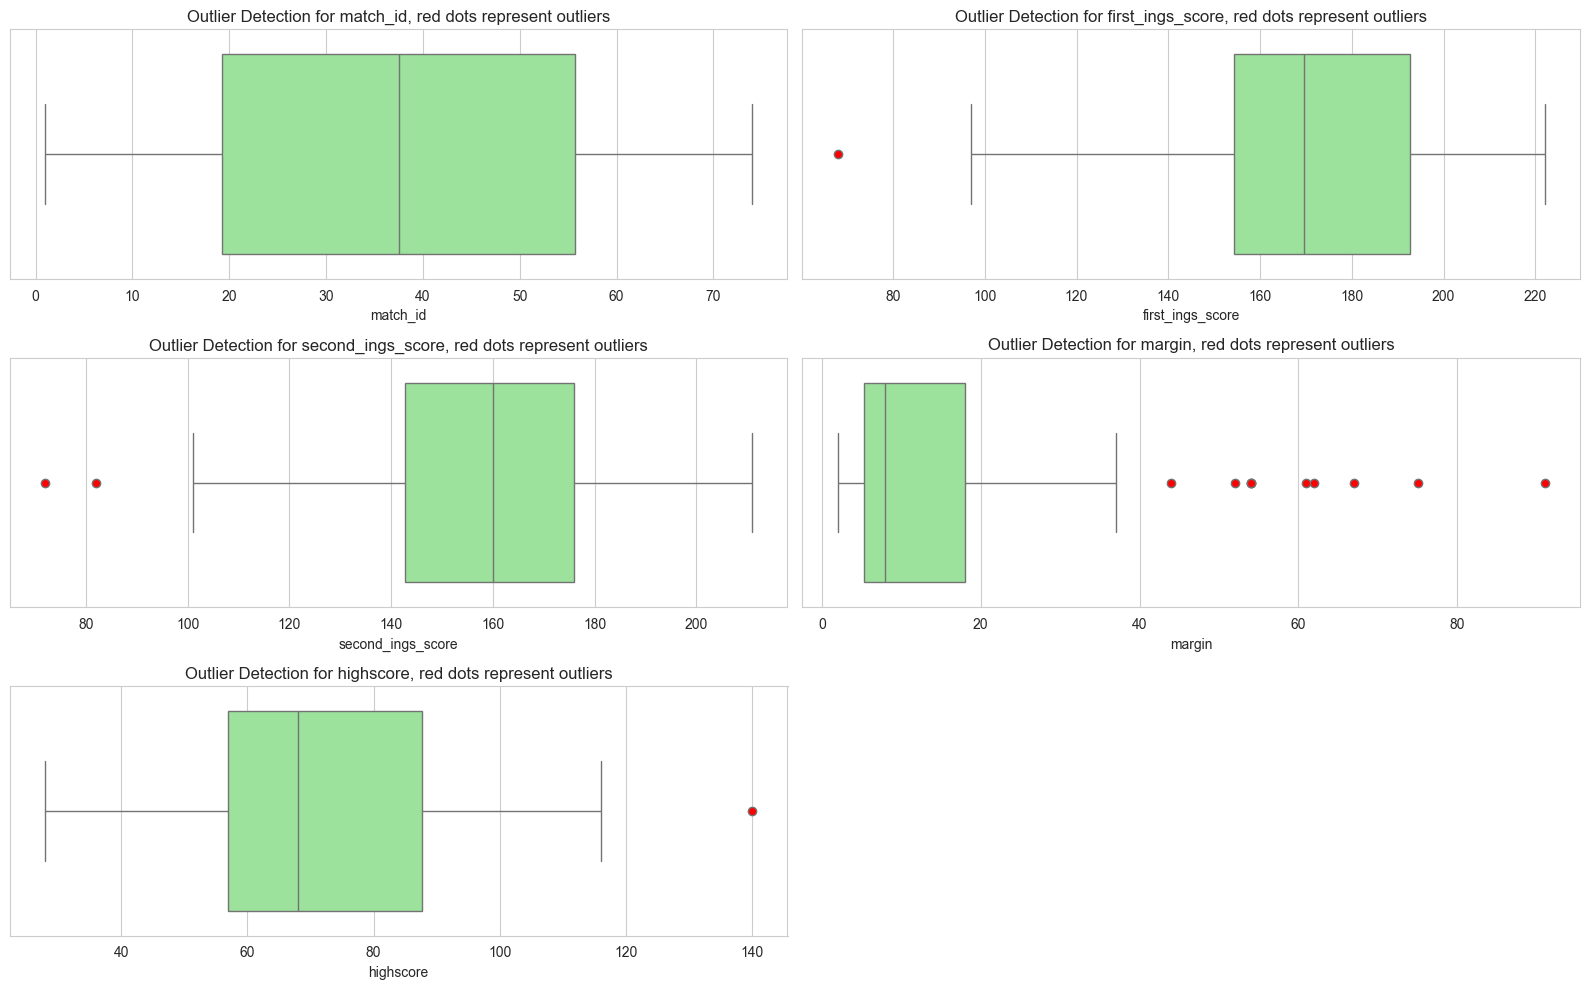

In [52]:
# showcasing outliers using boxplot for the discrete and continuous data attributes

if len(discrete_cols) >= 1:

    plt.figure(figsize=(16,10)) 
    
    print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    print("Outlier Analysis Using Boxplot")
    print("Red dots in the boxplot represent potential outliers detected using the IQR method")
    print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    

    for i in range(len(discrete_cols)):

        col = discrete_cols[i]

        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

        outlier_percentage = (len(outliers) / len(df)) * 100

        
        print(f"\nColumn : {col}")
        print("Outlier Detection Method : IQR Method")
        print(f"Q1 (25th percentile) : {Q1}")
        print(f"Q3 (75th percentile) : {Q3}")
        print(f"IQR (Interquartile Range) : {IQR}")
        print(f"Lower Bound : {lower_bound}")
        print(f"Upper Bound : {upper_bound}")
        print(f"Total Outliers Detected : {len(outliers)}")
        print(f"Outlier Percentage : {outlier_percentage:.2f}%")

        if len(outliers) > 0:
            print(f"Minimum Outlier Value : {outliers.min()}")
            print(f"Maximum Outlier Value : {outliers.max()}")
        else:
            print("No Outliers Detected")

        # ----- BOXPLOT -----
        plt.subplot(int(len(discrete_cols)/2) + 1, 2, i+1)

        sns.boxplot(
            x=df[col],
            flierprops=dict(marker='o', markerfacecolor='red', markersize=6),
            color="lightgreen"
        )

        plt.title(f"Outlier Detection for {col}, red dots represent outliers")
        plt.xlabel(col)

    plt.tight_layout()
    plt.show()

if len(continuous_cols)>=1:
        plt.figure(figsize=(16,10)) 
    
        print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")
        print("Outlier Analysis Using Boxplot")
        print("Red dots in the boxplot represent potential outliers detected using the IQR method")
        print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    

        for i in range(len(discrete_cols)):

            col = discrete_cols[i]

            # ----- IQR OUTLIER CALCULATION -----
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

            outlier_percentage = (len(outliers) / len(df)) * 100

            
            print(f"\nColumn : {col}")
            print("Outlier Detection Method : IQR Method")
            print(f"Q1 (25th percentile) : {Q1}")
            print(f"Q3 (75th percentile) : {Q3}")
            print(f"IQR (Interquartile Range) : {IQR}")
            print(f"Lower Bound : {lower_bound}")
            print(f"Upper Bound : {upper_bound}")
            print(f"Total Outliers Detected : {len(outliers)}")
            print(f"Outlier Percentage : {outlier_percentage:.2f}%")

            if len(outliers) > 0:
                print(f"Minimum Outlier Value : {outliers.min()}")
                print(f"Maximum Outlier Value : {outliers.max()}")
            else:
                print("No Outliers Detected")

            
            plt.subplot(int(len(discrete_cols)/2) + 1, 2, i+1)

            sns.boxplot(
                x=df[col],
                flierprops=dict(marker='o', markerfacecolor='red', markersize=6),
                color="lightgreen"
            )

            plt.title(f"Outlier Detection for {col}, red dots represent outliers")
            plt.xlabel(col)

        plt.tight_layout()
        plt.show()
    
    

****************************************************************************************************
Representation of Skewness in Numeric Columns
Histogram along with KDE curve helps visualize the distribution of the data.
Skewness indicates whether the data distribution is symmetric or skewed due to extreme values.
Positive Skewness  => Tail on the right side (large values / high outliers)
Negative Skewness  => Tail on the left side (small values / low outliers)
Near Zero Skewness => Approximately symmetric distribution
****************************************************************************************************

Column : match_id
Skewness Value : 0.000
Interpretation : Approximately Symmetric
Minimum Value : 1
Maximum Value : 74
Mean : 37.50
Median : 37.50

Column : first_ings_score
Skewness Value : -0.670
Interpretation : Moderately Negatively Skewed
Minimum Value : 68
Maximum Value : 222
Mean : 171.12
Median : 169.50

Column : second_ings_score
Skewness Value : -0.526
Inter

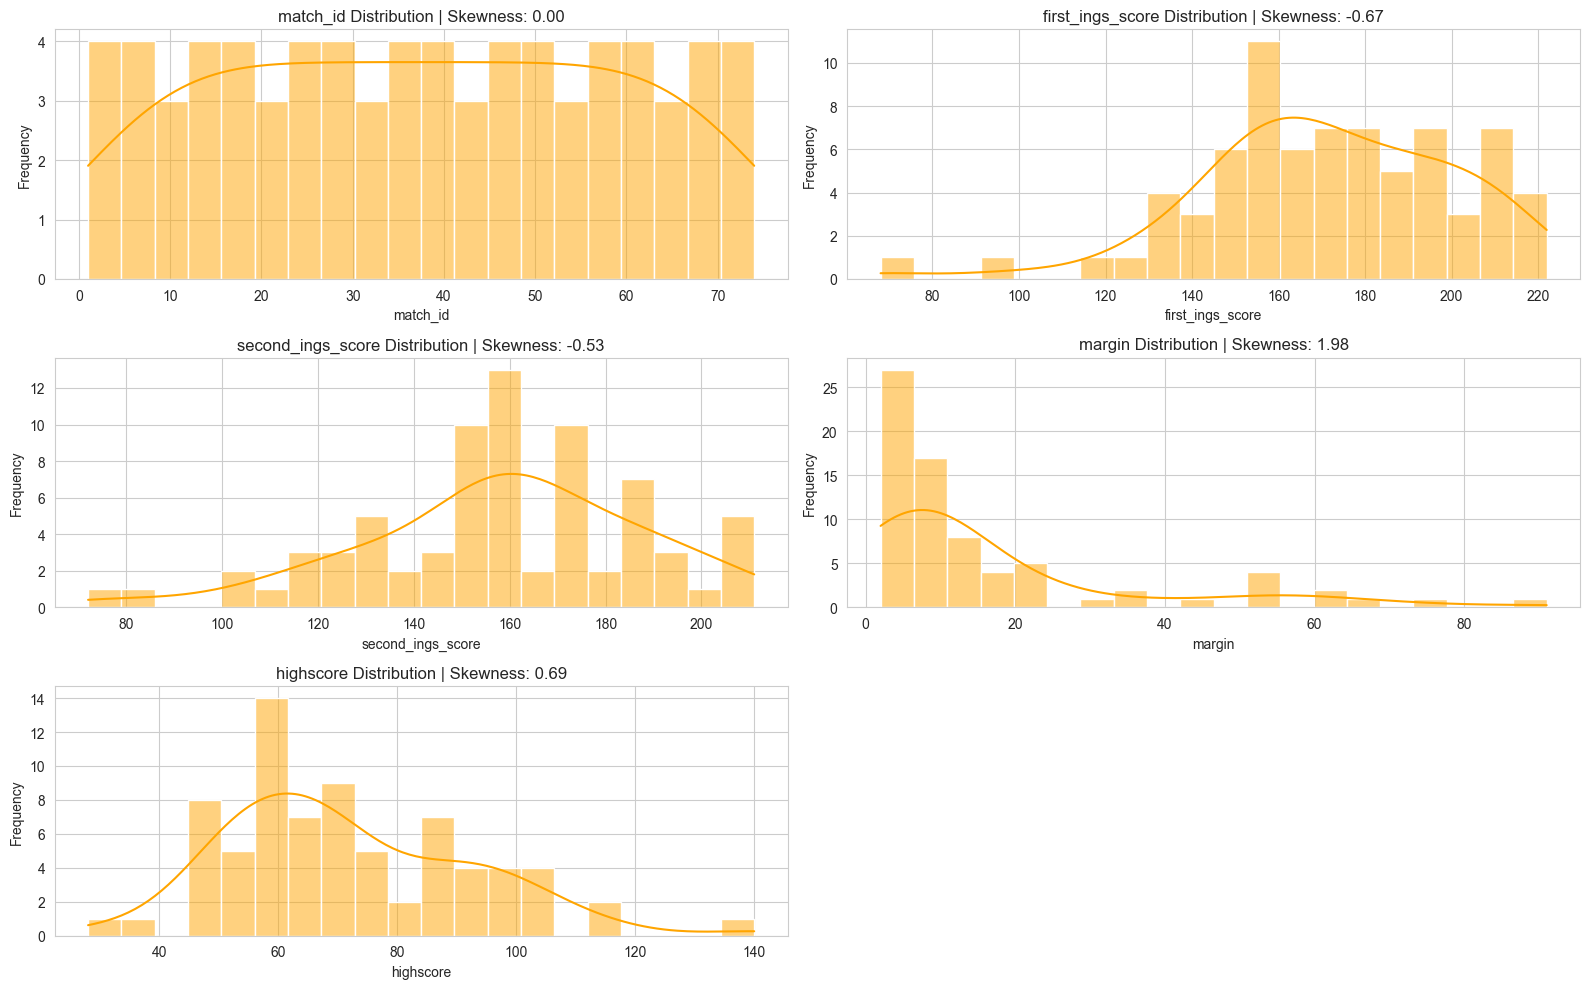

In [53]:
# showcasing skewness of the numeric cols 
if len(discrete_cols) >=1:

    plt.figure(figsize=(16,10))

    print("*"*100)
    print("Representation of Skewness in Numeric Columns")
    print("Histogram along with KDE curve helps visualize the distribution of the data.")
    print("Skewness indicates whether the data distribution is symmetric or skewed due to extreme values.")
    print("Positive Skewness  => Tail on the right side (large values / high outliers)")
    print("Negative Skewness  => Tail on the left side (small values / low outliers)")
    print("Near Zero Skewness => Approximately symmetric distribution")
    print("*"*100)

    for i in range(len(discrete_cols)):

        col = discrete_cols[i]

        skew_value = df[col].skew()

        
        if skew_value > 1:
            interpretation = "Highly Positively Skewed (Strong Right Tail)"
        elif skew_value > 0.5:
            interpretation = "Moderately Positively Skewed"
        elif skew_value < -1:
            interpretation = "Highly Negatively Skewed (Strong Left Tail)"
        elif skew_value < -0.5:
            interpretation = "Moderately Negatively Skewed"
        else:
            interpretation = "Approximately Symmetric"

        print(f"\nColumn : {col}")
        print(f"Skewness Value : {skew_value:.3f}")
        print(f"Interpretation : {interpretation}")
        print(f"Minimum Value : {df[col].min()}")
        print(f"Maximum Value : {df[col].max()}")
        print(f"Mean : {df[col].mean():.2f}")
        print(f"Median : {df[col].median():.2f}")

        plt.subplot(int(len(discrete_cols)/2)+1,2,i+1)

        sns.histplot(df[col], kde=True, bins=20, color="orange")

        plt.title(f"{col} Distribution | Skewness: {skew_value:.2f}")
        plt.xlabel(col)
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

if len(continuous_cols) >=1:

    plt.figure(figsize=(16,10))

    print("*"*100)
    print("Representation of Skewness in Numeric Columns")
    print("Histogram along with KDE curve helps visualize the distribution of the data.")
    print("Skewness indicates whether the data distribution is symmetric or skewed due to extreme values.")
    print("Positive Skewness  => Tail on the right side (large values / high outliers)")
    print("Negative Skewness  => Tail on the left side (small values / low outliers)")
    # print("Near Zero Skewness => Approximately symmetric distribution")
    print("*"*100)

    for i in range(len(discrete_cols)):

        col = discrete_cols[i]

        skew_value = df[col].skew()

        
        if skew_value > 1:
            interpretation = "Highly Positively Skewed (Strong Right Tail)"
        elif skew_value > 0.5:
            interpretation = "Moderately Positively Skewed"
        elif skew_value < -1:
            interpretation = "Highly Negatively Skewed (Strong Left Tail)"
        elif skew_value < -0.5:
            interpretation = "Moderately Negatively Skewed"
        else:
            interpretation = "Approximately Symmetric"

        print(f"\nColumn : {col}")
        print(f"Skewness Value : {skew_value:.3f}")
        print(f"Interpretation : {interpretation}")
        print(f"Minimum Value : {df[col].min()}")
        print(f"Maximum Value : {df[col].max()}")
        print(f"Mean : {df[col].mean():.2f}")
        print(f"Median : {df[col].median():.2f}")

        plt.subplot(int(len(discrete_cols)/2)+1,2,i+1)

        sns.histplot(df[col], kde=True, bins=20, color="orange")

        plt.title(f"{col} Distribution | Skewness: {skew_value:.2f}")
        plt.xlabel(col)
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


 BINARY COLUMNS ANALYSIS

Binary columns (like 0/1, Yes/No or any two unique values).

# Countplot => shows exact count  
# Pie Chart => shows proportion (%)



C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2760492089.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2760492089.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


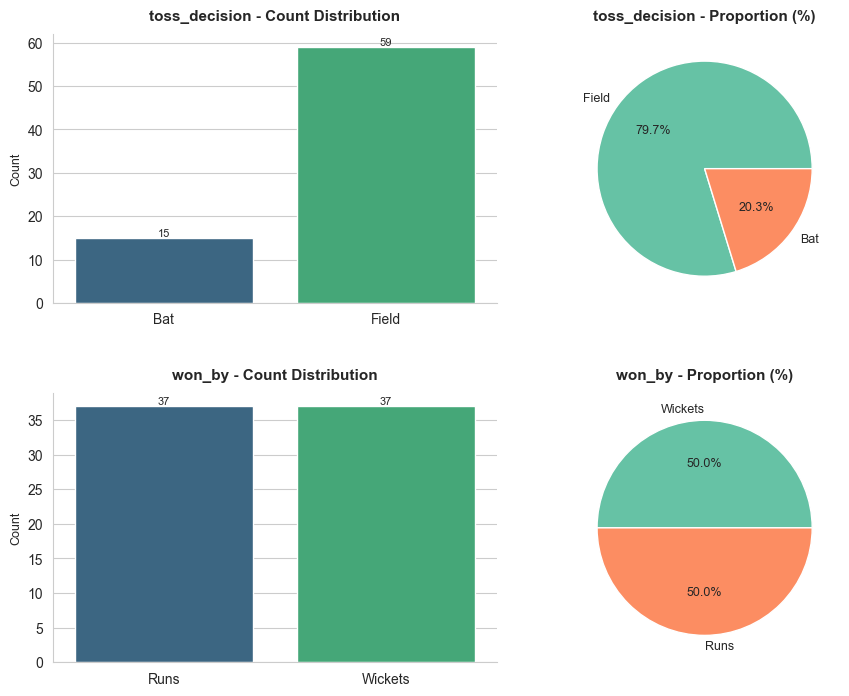


 RELATIONSHIP ANALYSIS (PAIRPLOT)

Pairplot is used to demonstrate relationships between features:

• Same color → same class  
• Different color → different class


--- Pairplot for: toss_decision ---



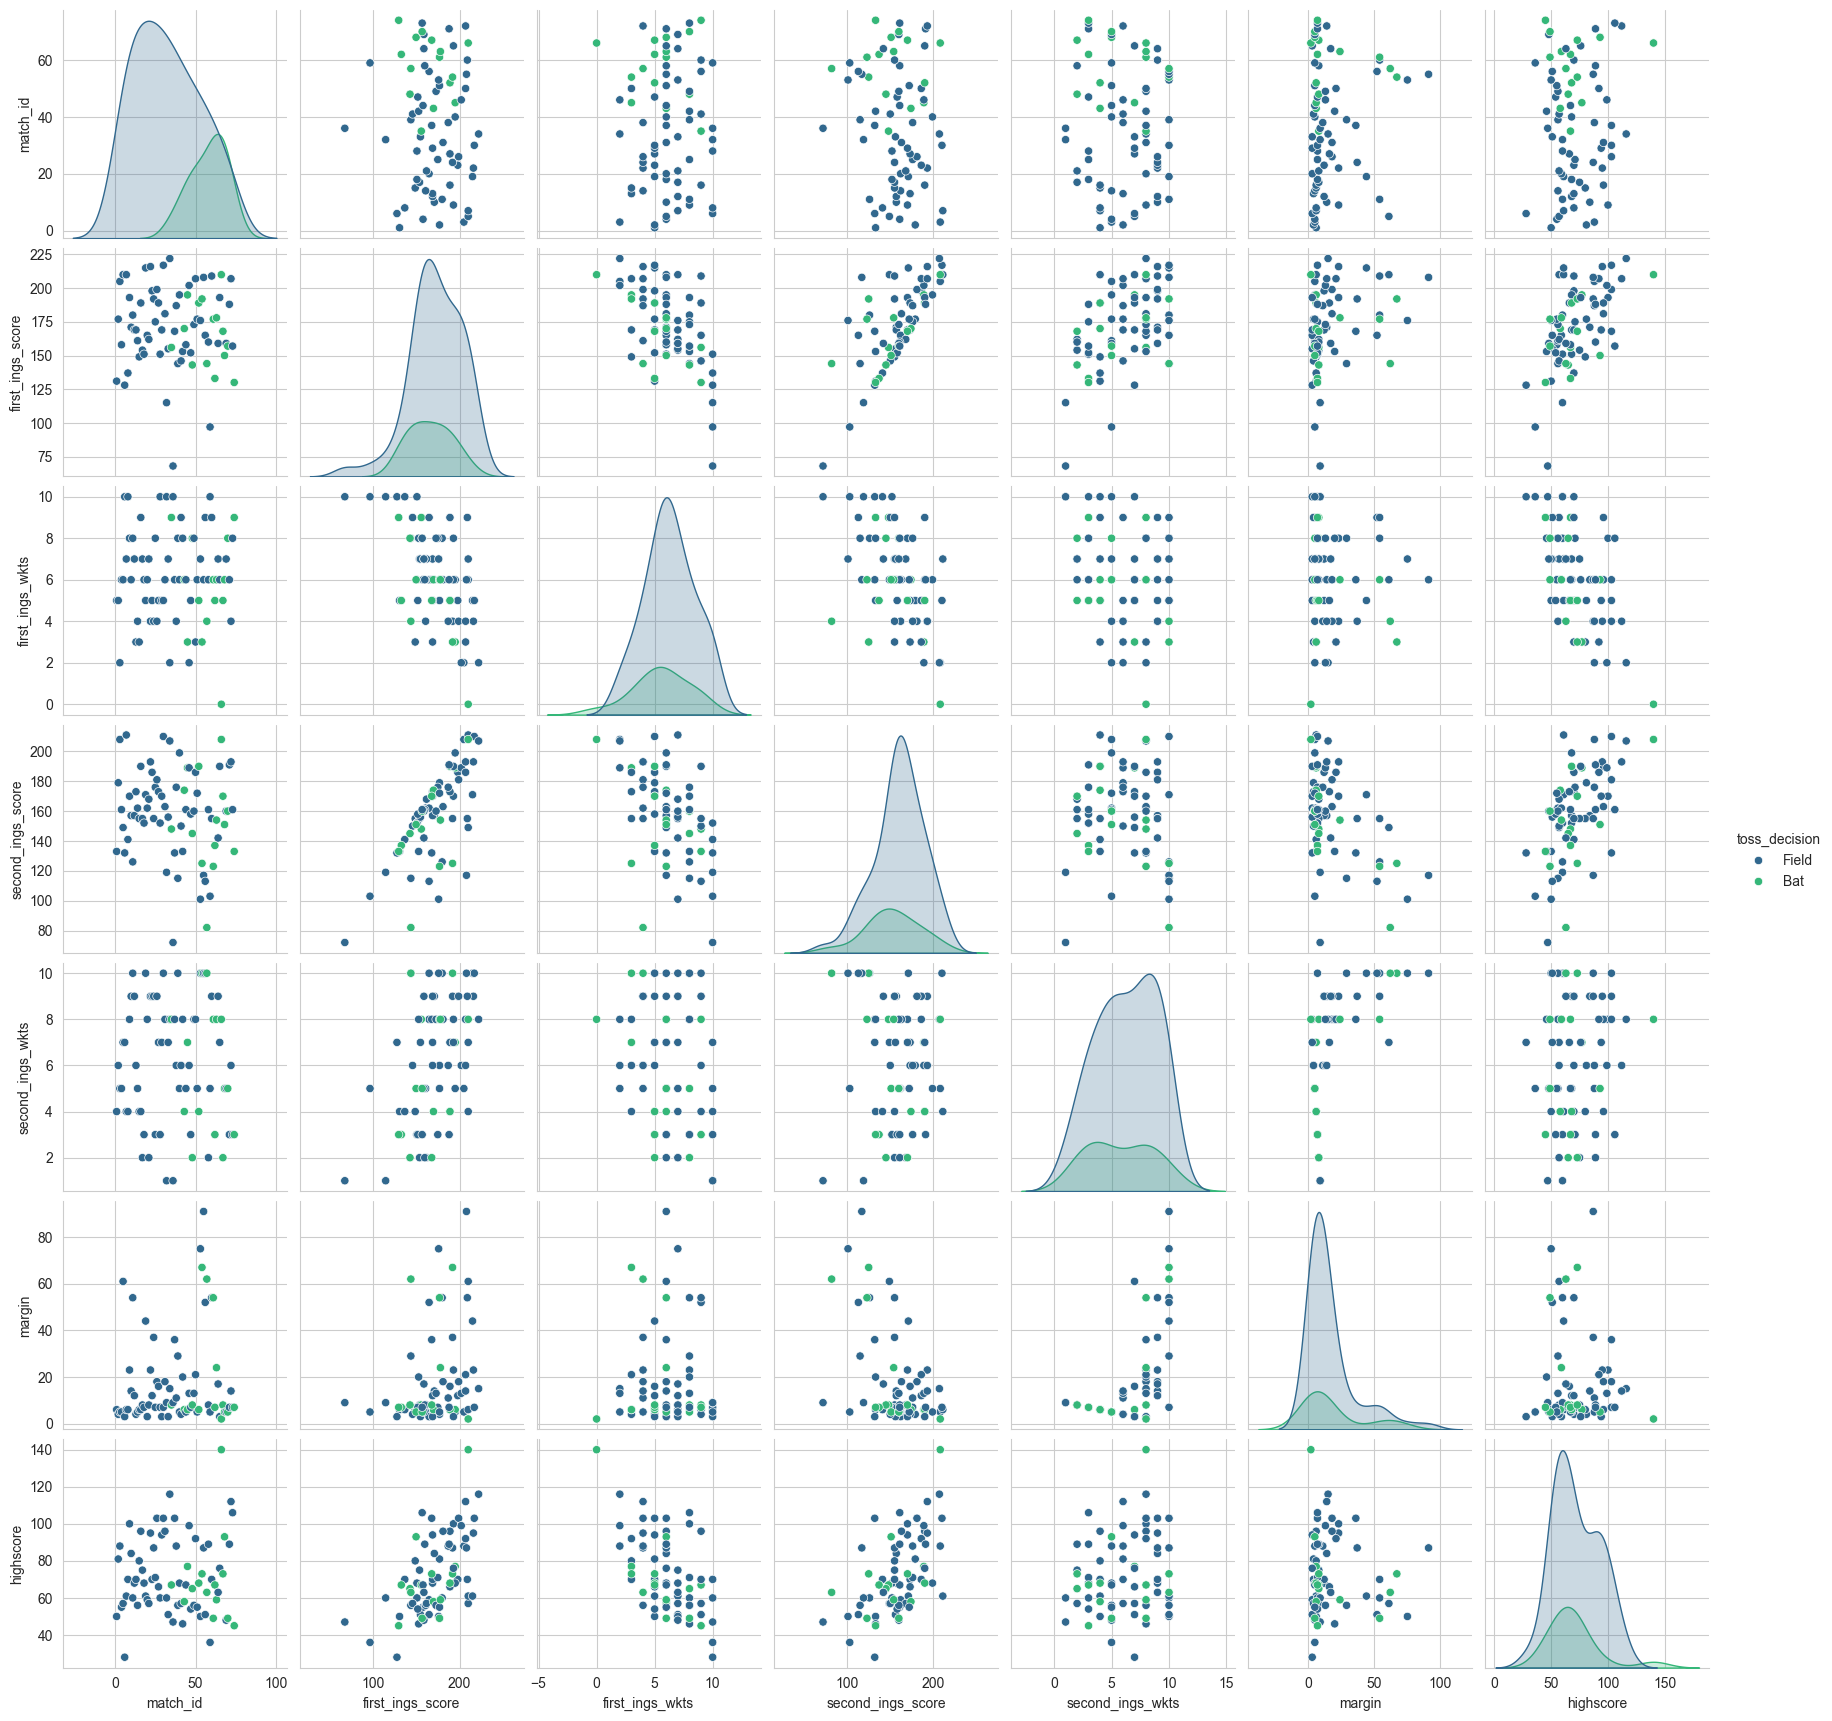


--- Pairplot for: won_by ---



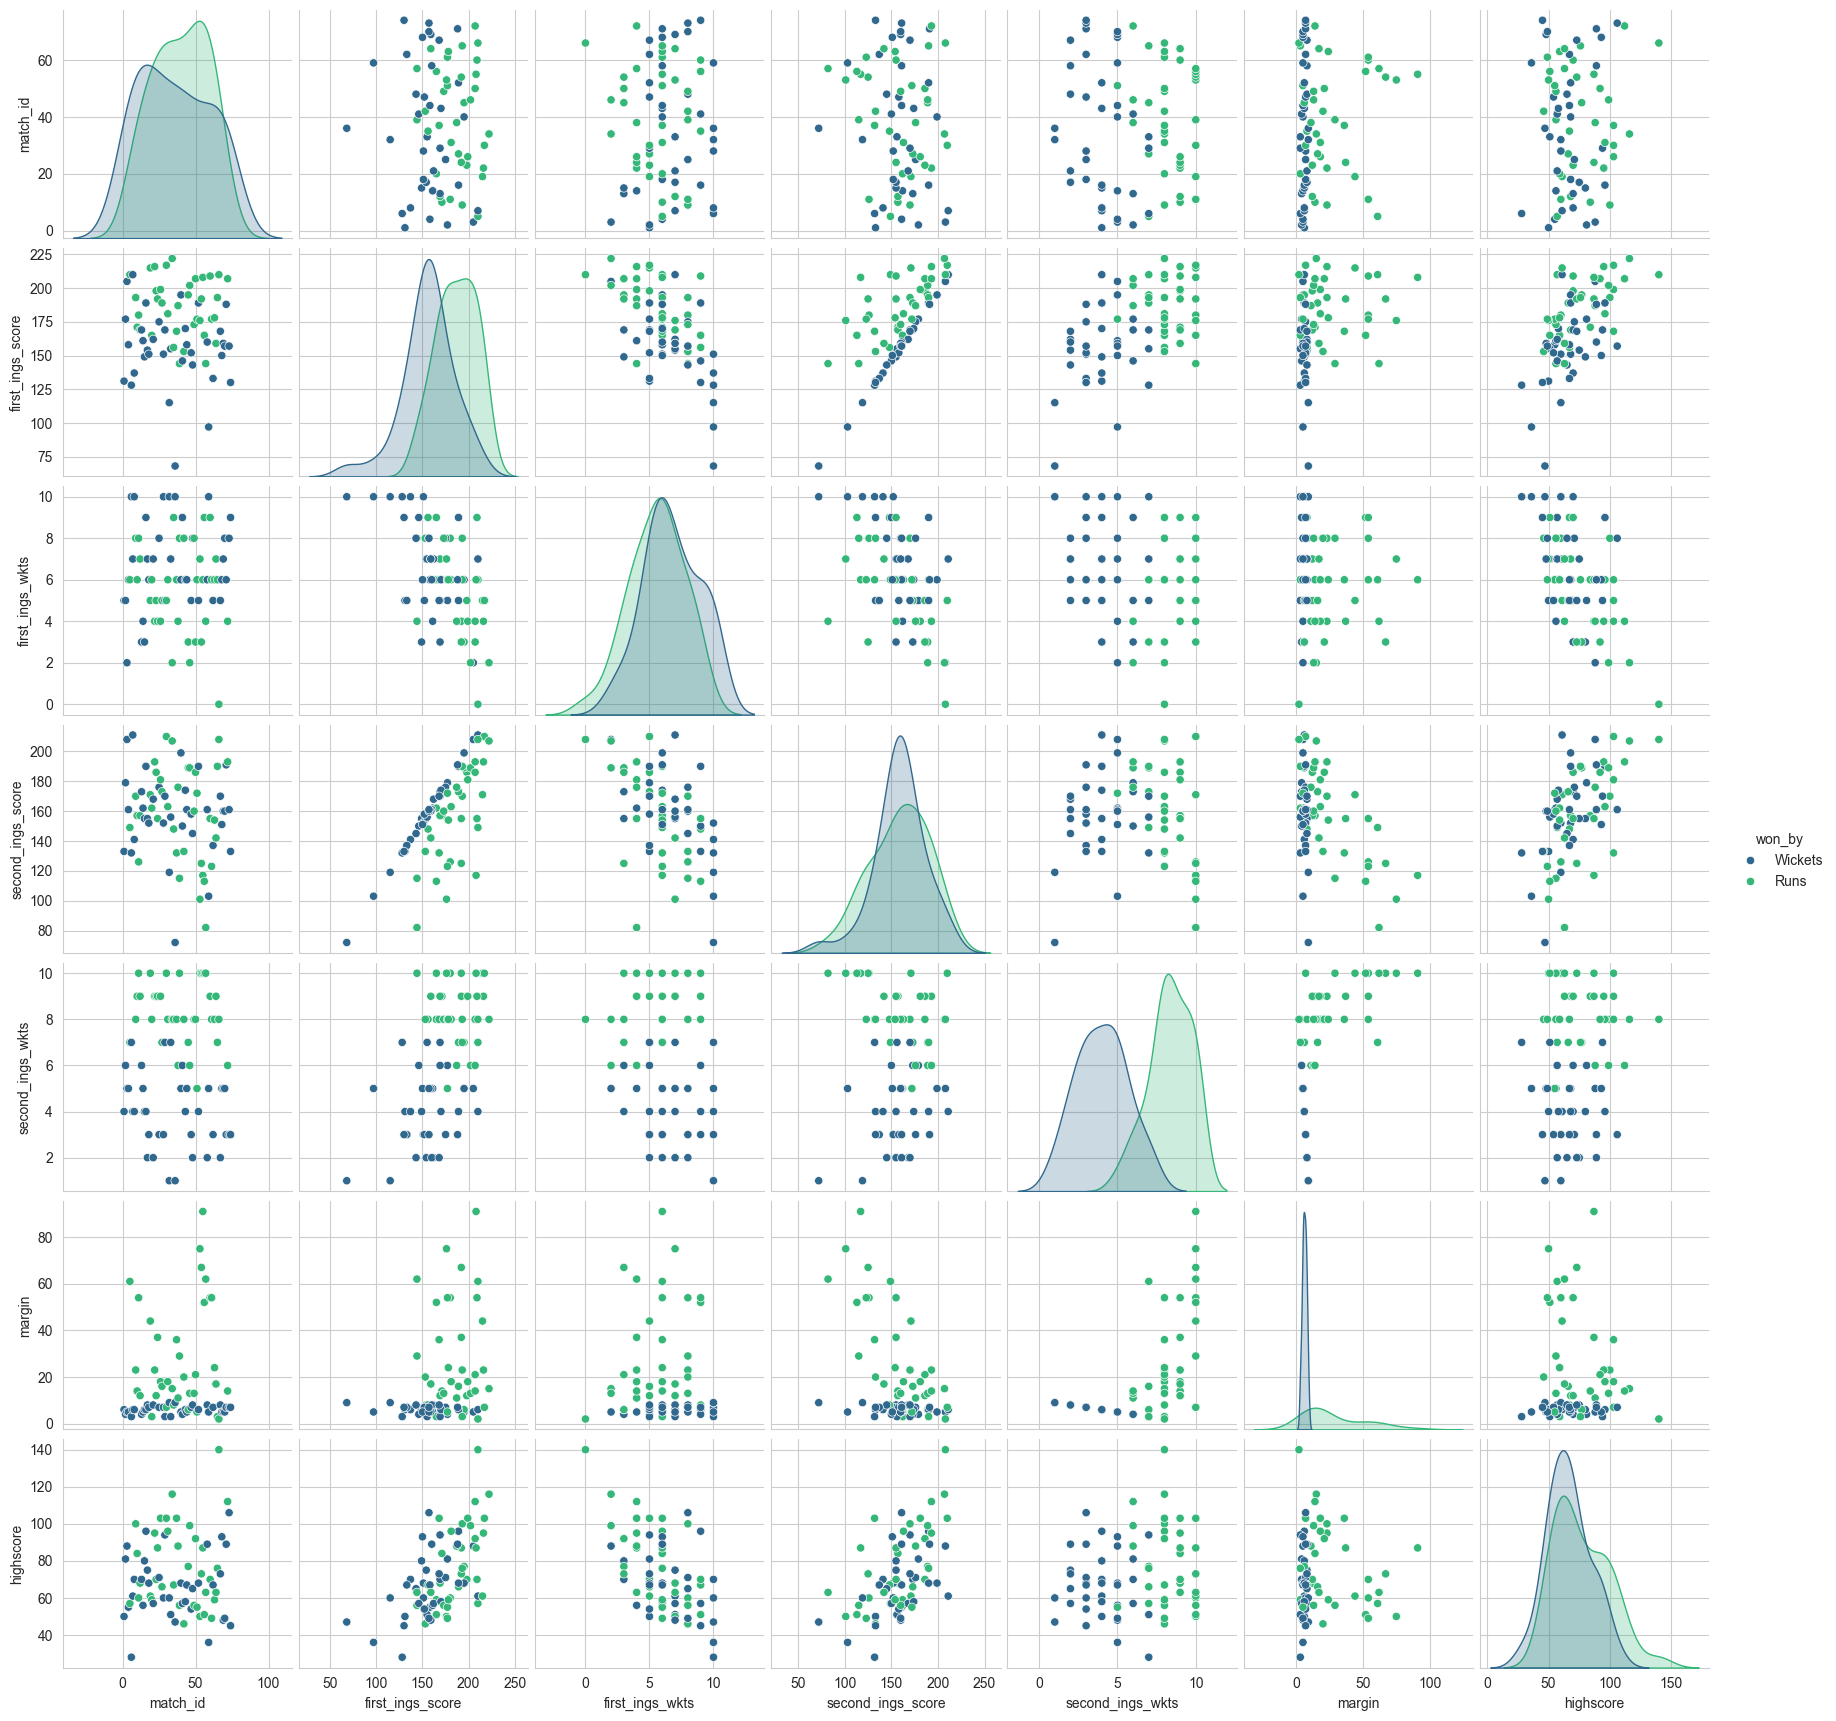

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("\n" + "="*70)
print(" BINARY COLUMNS ANALYSIS")
print("="*70)

print("""
Binary columns (like 0/1, Yes/No or any two unique values).

# Countplot => shows exact count  
# Pie Chart => shows proportion (%)
""")


n_cols = 2
n_rows = len(binary_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3.8*n_rows))

if n_rows == 1:
    axes = [axes]

for i, col in enumerate(binary_cols):


    ax1 = axes[i][0]
    
    sns.countplot(
        x=col,
        data=df,
        order=sorted(df[col].dropna().unique()),
        palette="viridis",  
        ax=ax1
    )
    
    ax1.set_title(f"{col} - Count Distribution", fontsize=11, fontweight='bold', pad=10)
    ax1.set_xlabel("")
    ax1.set_ylabel("Count", fontsize=9)

    # Value labels
    for p in ax1.patches:
        ax1.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=8
        )

    # Clean look
    ax1.spines[['top','right']].set_visible(False)

    
    ax2 = axes[i][1]
    
    counts = df[col].value_counts()
    
    ax2.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=sns.color_palette("Set2", len(counts)), 
        textprops={'fontsize':9}
    )
    
    ax2.set_title(f"{col} - Proportion (%)", fontsize=11, fontweight='bold', pad=10)

# Better spacing
plt.subplots_adjust(hspace=0.6, wspace=0.3)
plt.tight_layout(pad=3)
plt.show()



print("\n" + "="*70)
print(" RELATIONSHIP ANALYSIS (PAIRPLOT)")
print("="*70)

print("""
Pairplot is used to demonstrate relationships between features:

• Same color → same class  
• Different color → different class
""")

# Separate clean pairplots
for col in binary_cols:
    print(f"\n--- Pairplot for: {col} ---\n")
    
    sns.pairplot(
        df,
        hue=col,
        palette="viridis",
        diag_kind="kde"
    )
    
    plt.show()

Analyzing Ordinal Feature: first_ings_wkts


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\4075643290.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


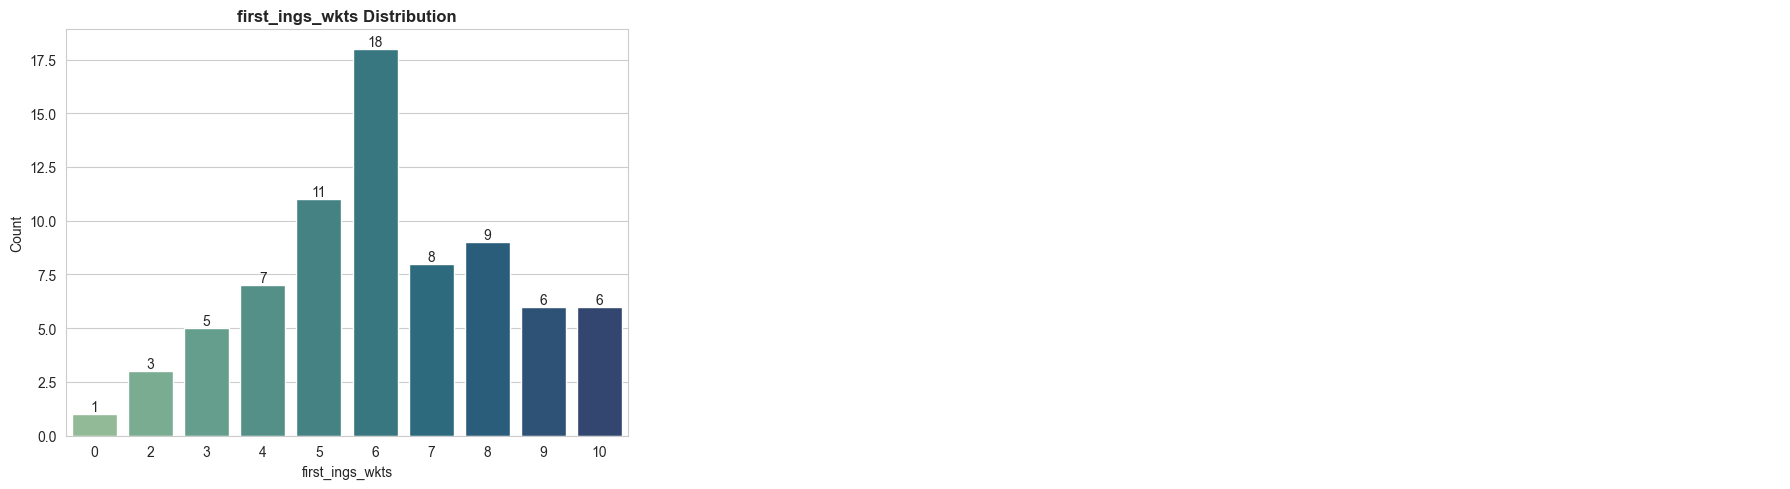

Analyzing Ordinal Feature: second_ings_wkts


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\4075643290.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


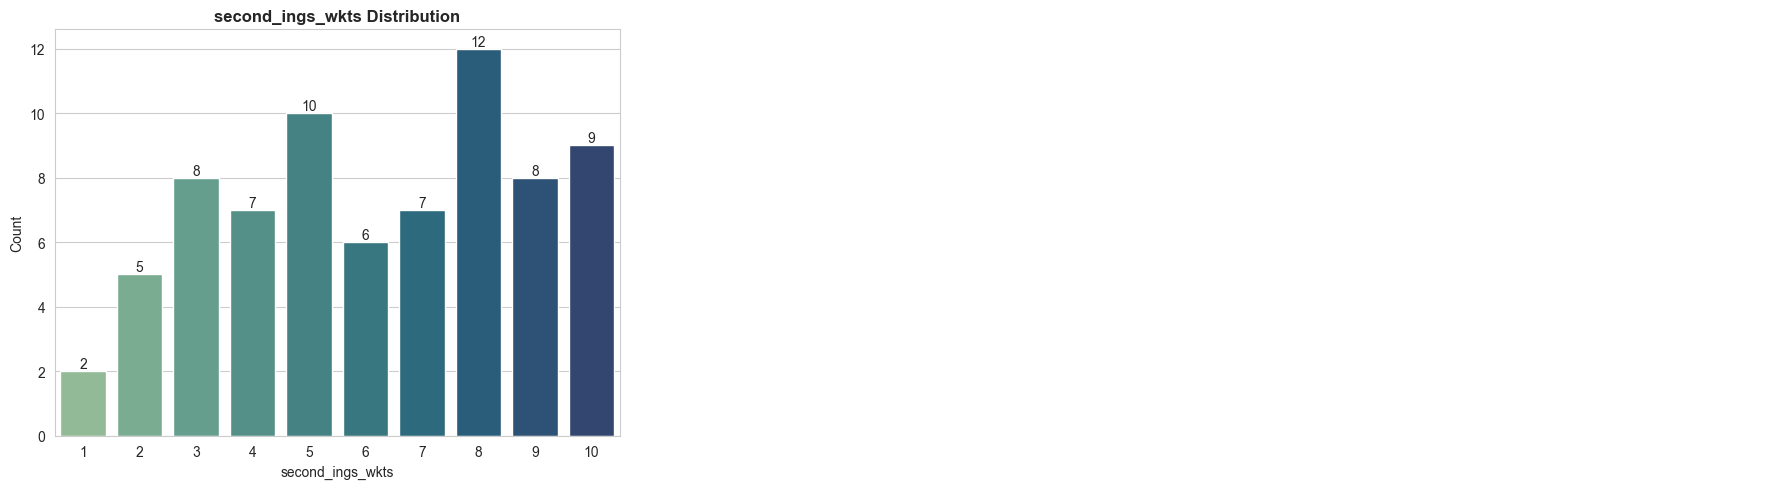

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

def visualize_ordinal_features_no_target(df, ordinal_cols, continuous_cols=None):
    
    for col in ordinal_cols:
        print("="*80)
        print(f"Analyzing Ordinal Feature: {col}")
        print("="*80)
        
        order = sorted(df[col].dropna().unique())
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        
        ax1 = axes[0]
        sns.countplot(
            x=col,
            data=df,
            order=order,
            palette="crest",
            ax=ax1
        )
        
        ax1.set_title(f"{col} Distribution", fontweight='bold')
        ax1.set_xlabel(col)
        ax1.set_ylabel("Count")
        
        for p in ax1.patches:
            ax1.annotate(
                f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom'
            )
        
        
        ax2 = axes[1]
        
        freq = df[col].value_counts(normalize=True).reindex(order)
        
        sns.barplot(
            x=freq.index,
            y=freq.values,
            palette="viridis",
            ax=ax2
        )
        
        ax2.set_title(f"{col} Percentage Distribution")
        ax2.set_ylabel("Proportion")
        ax2.set_xlabel(col)
        
        
        ax3 = axes[2]
        
        if continuous_cols and len(continuous_cols) > 0:
            cont = continuous_cols[0]  # pick first
            
            grouped = df.groupby(col)[cont].mean().reindex(order)
            
            sns.lineplot(
                x=grouped.index,
                y=grouped.values,
                marker='o',
                ax=ax3
            )
            
            ax3.set_title(f"{col} vs Avg {cont} (Trend)")
            ax3.set_xlabel(col)
            ax3.set_ylabel(f"Mean {cont}")
        
        else:
            ax3.axis('off')
        
        plt.tight_layout()
        plt.show()

visualize_ordinal_features(
    df,
    ordinal_cols=ordinal_cols,
   
    continuous_cols=continuous_cols
)

Analyzing Categorical Feature: date


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


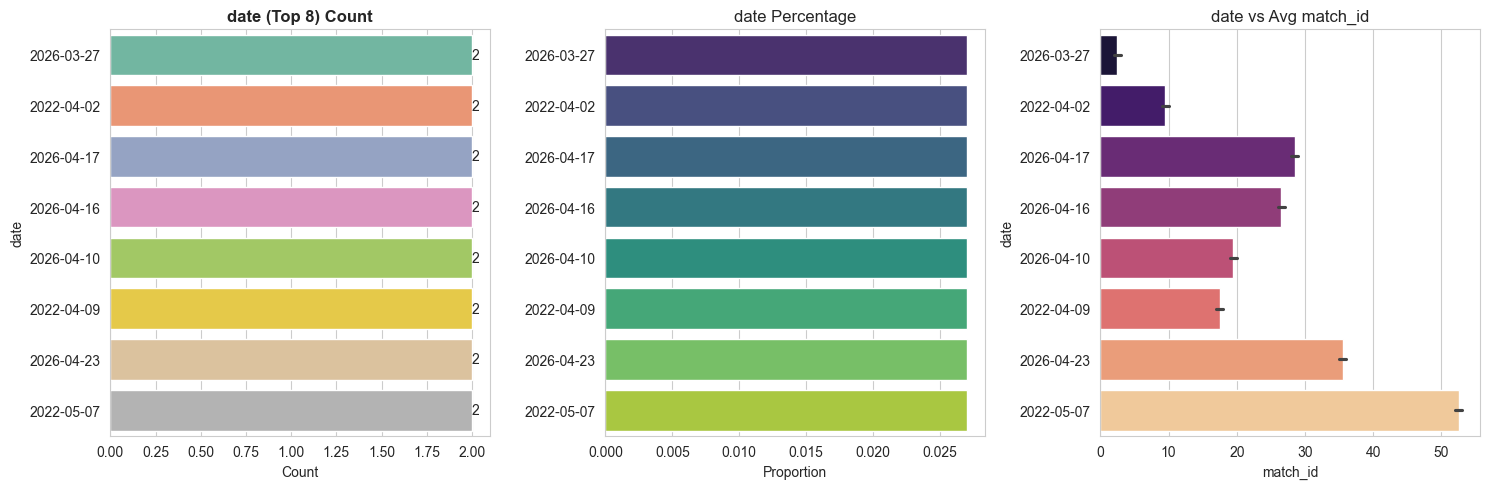

Analyzing Categorical Feature: venue


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


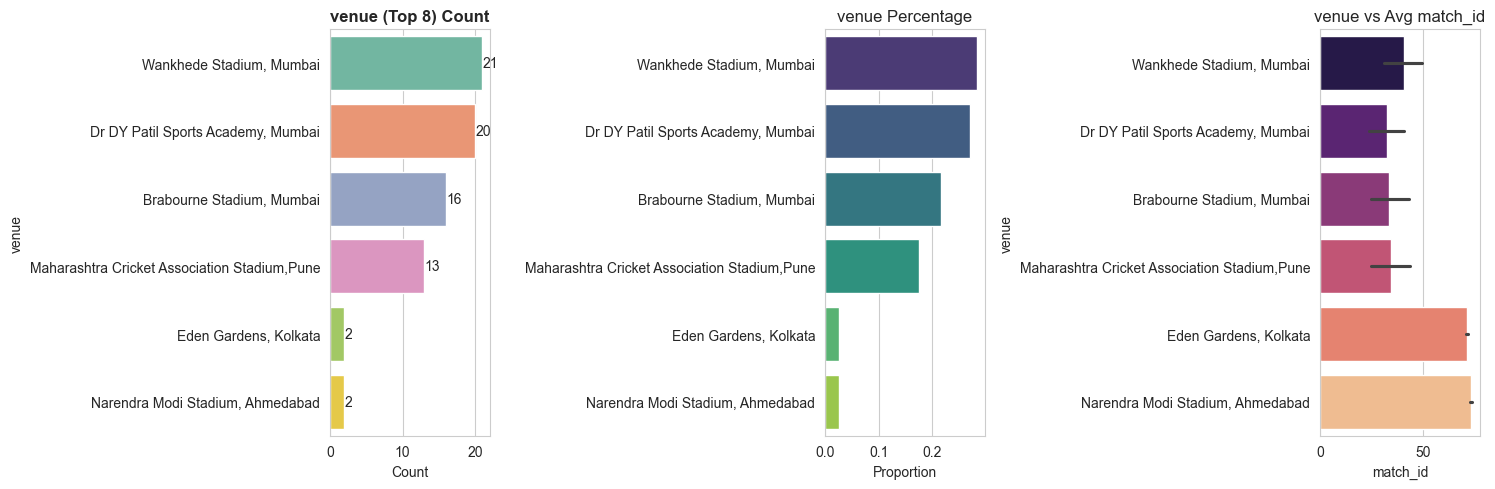

Analyzing Categorical Feature: team1


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


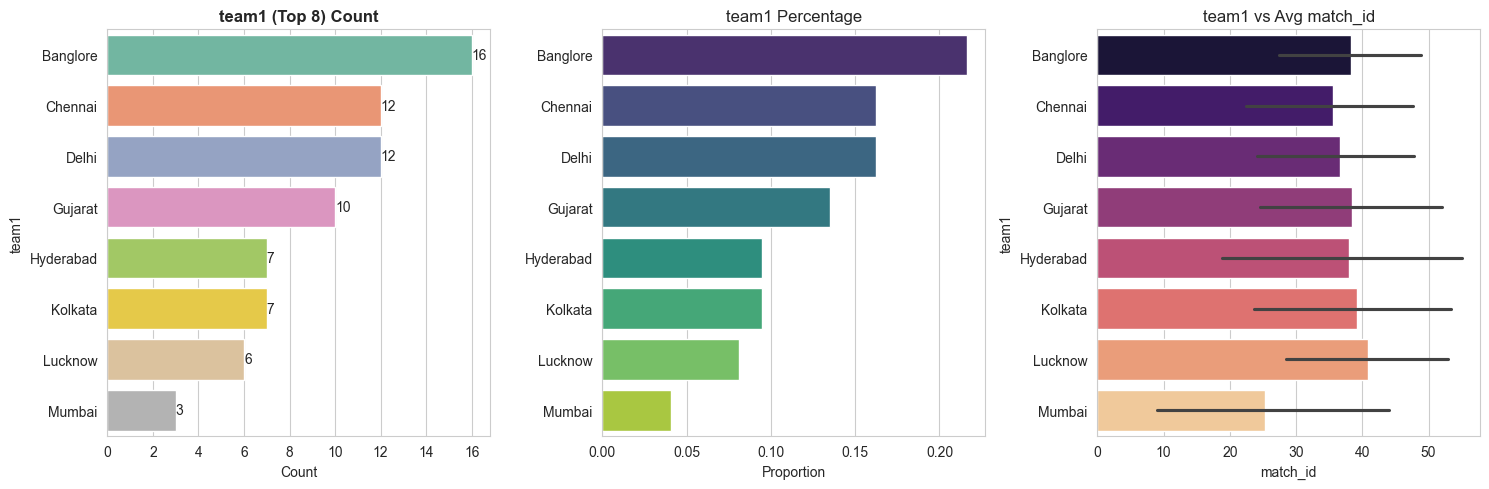

Analyzing Categorical Feature: team2


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


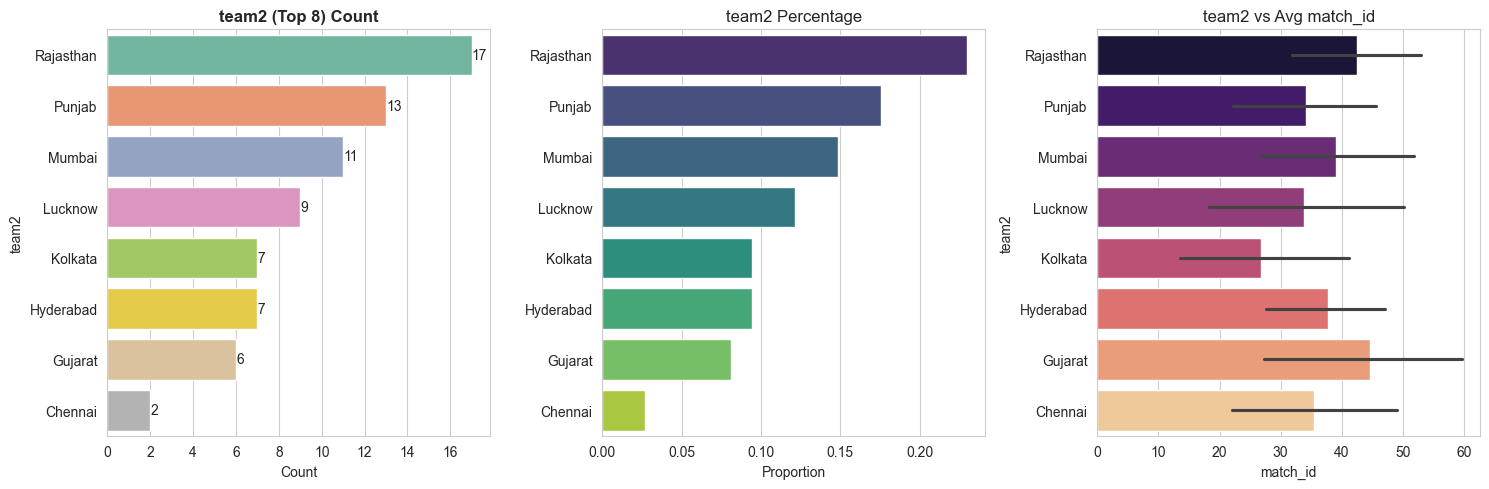

Analyzing Categorical Feature: stage


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


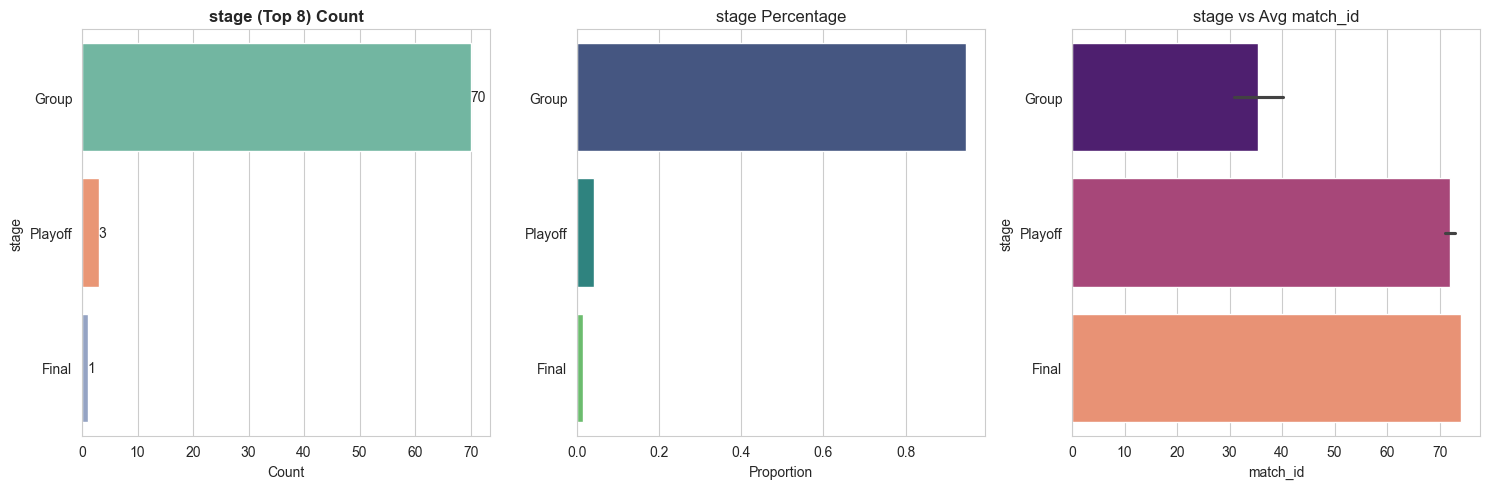

Analyzing Categorical Feature: toss_winner


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


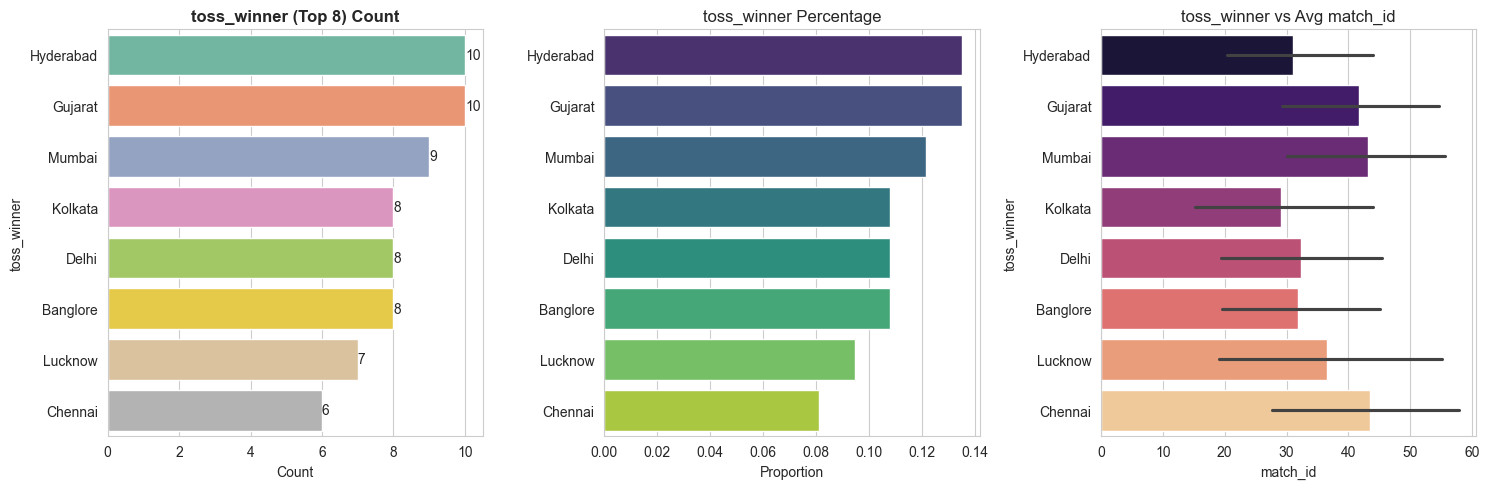

Analyzing Categorical Feature: match_winner


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


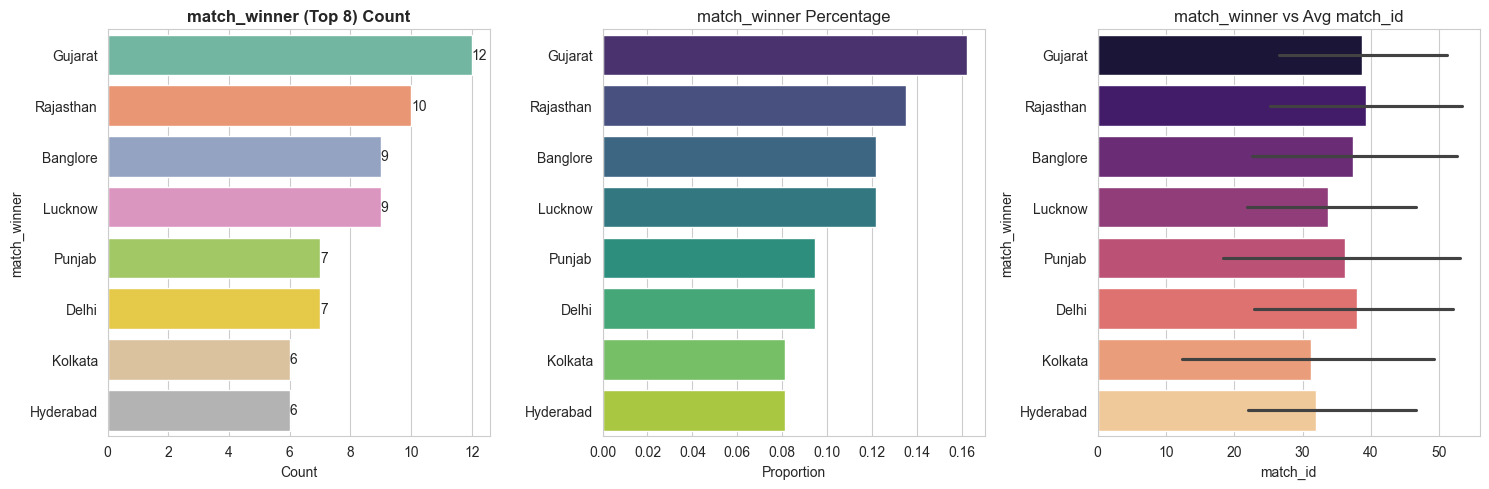

Analyzing Categorical Feature: player_of_the_match


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


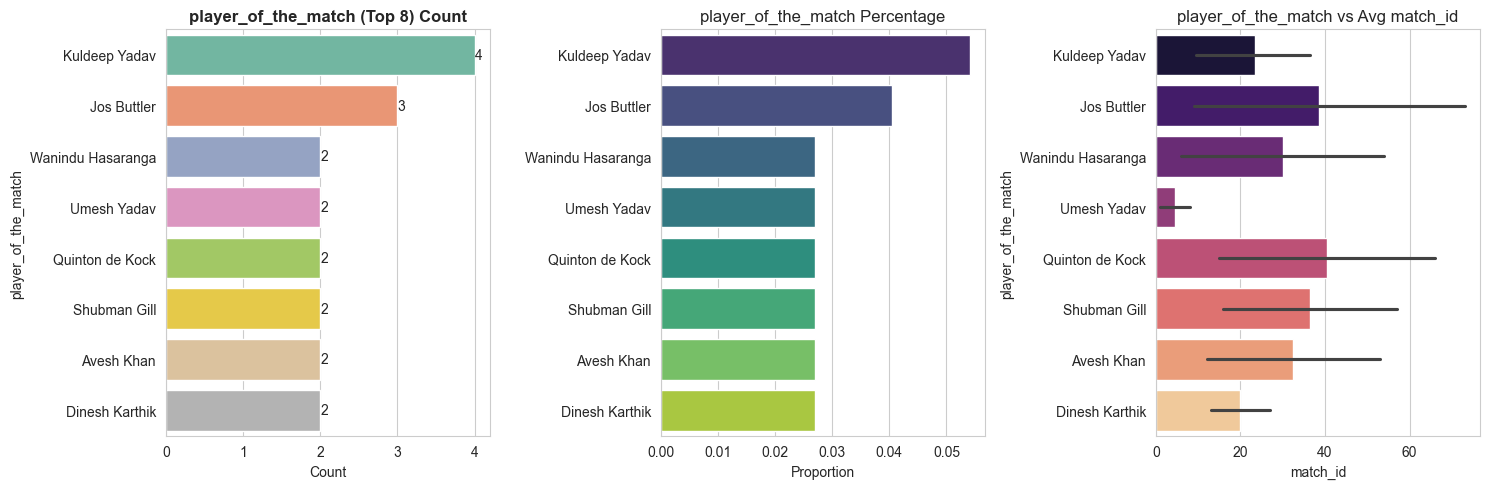

Analyzing Categorical Feature: top_scorer


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


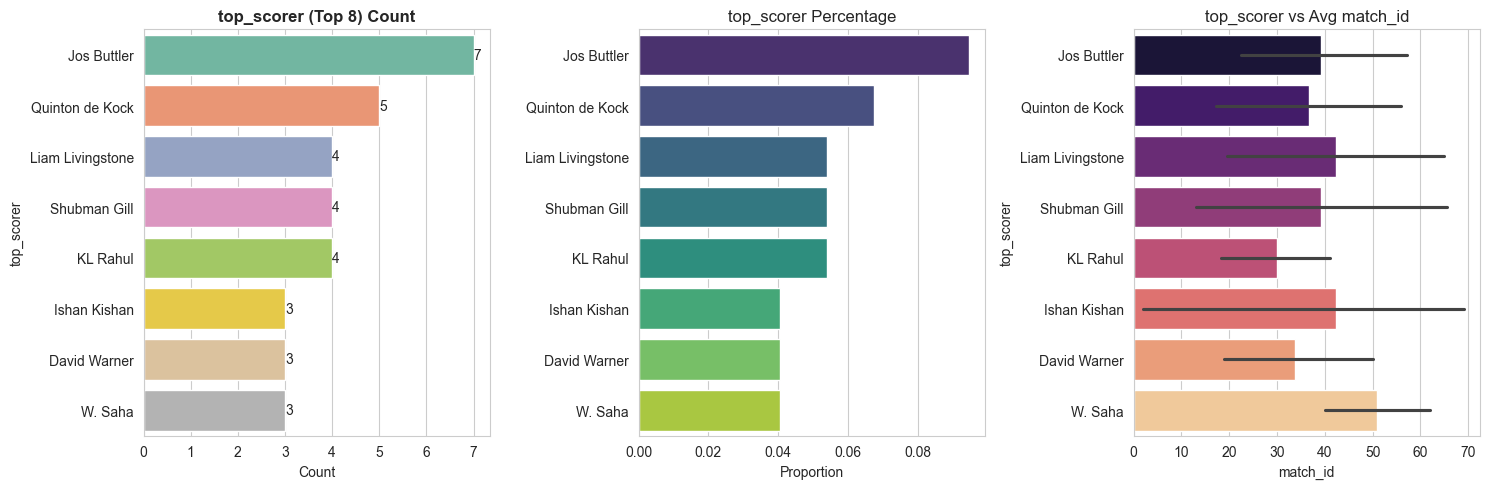

Analyzing Categorical Feature: best_bowling


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


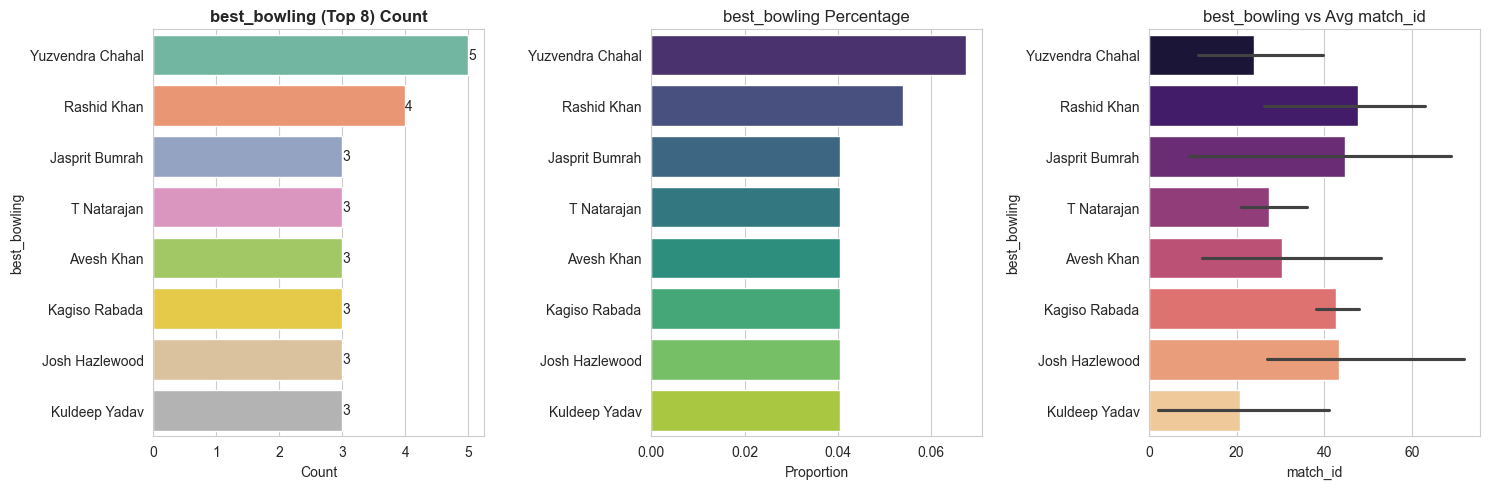

Analyzing Categorical Feature: best_bowling_figure


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


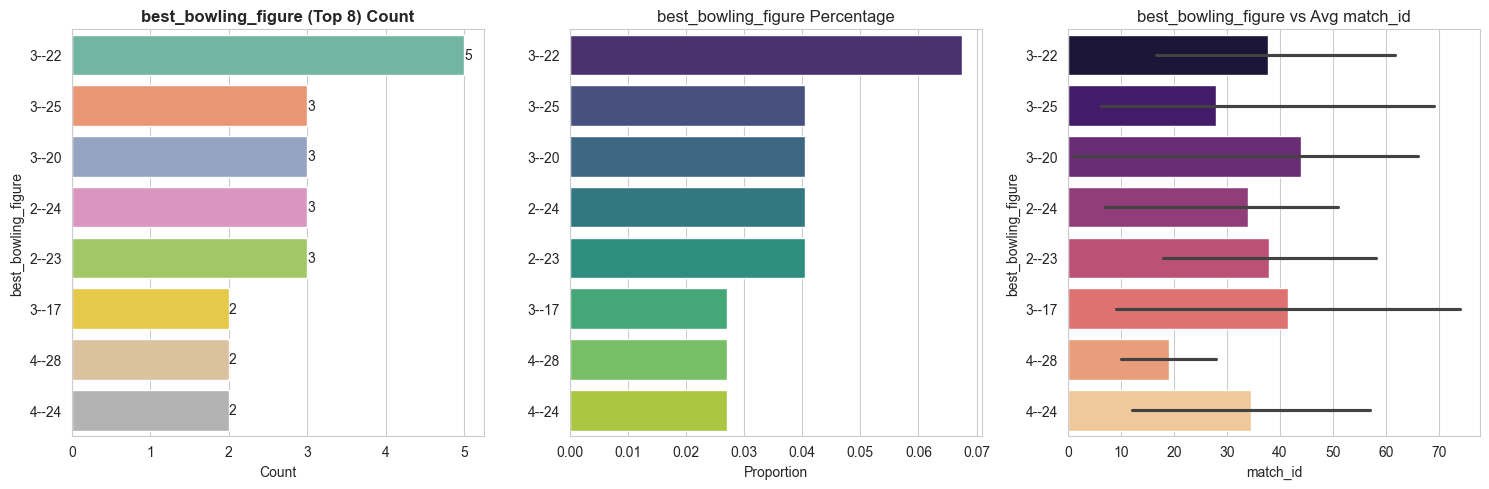

Analyzing Categorical Feature: bbh


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


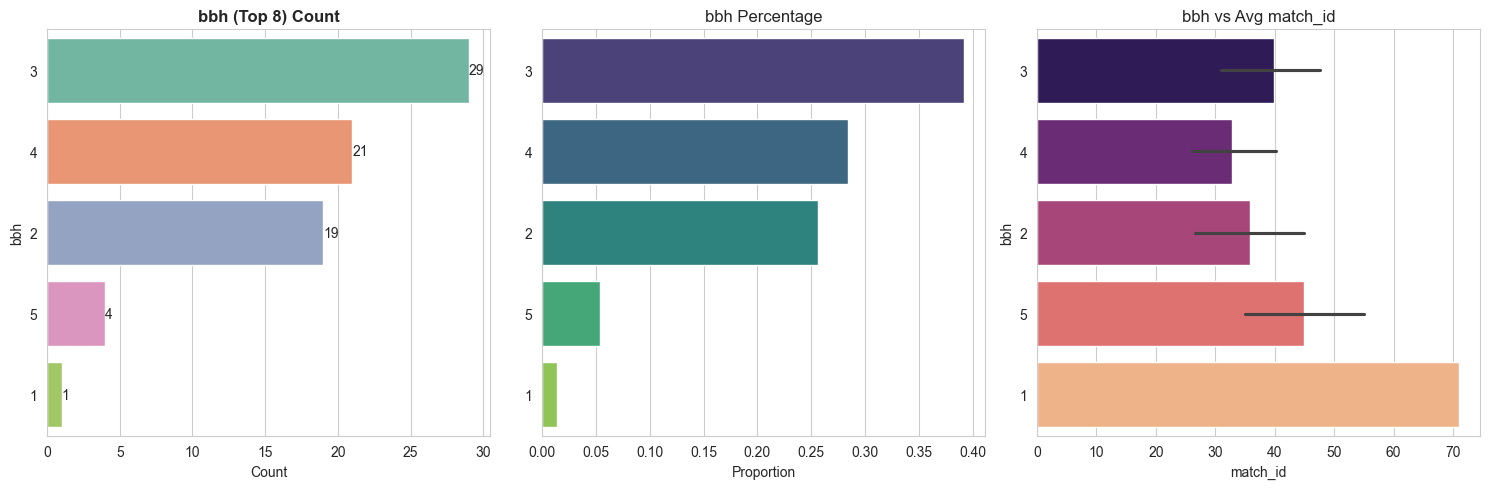

Analyzing Categorical Feature: hj


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


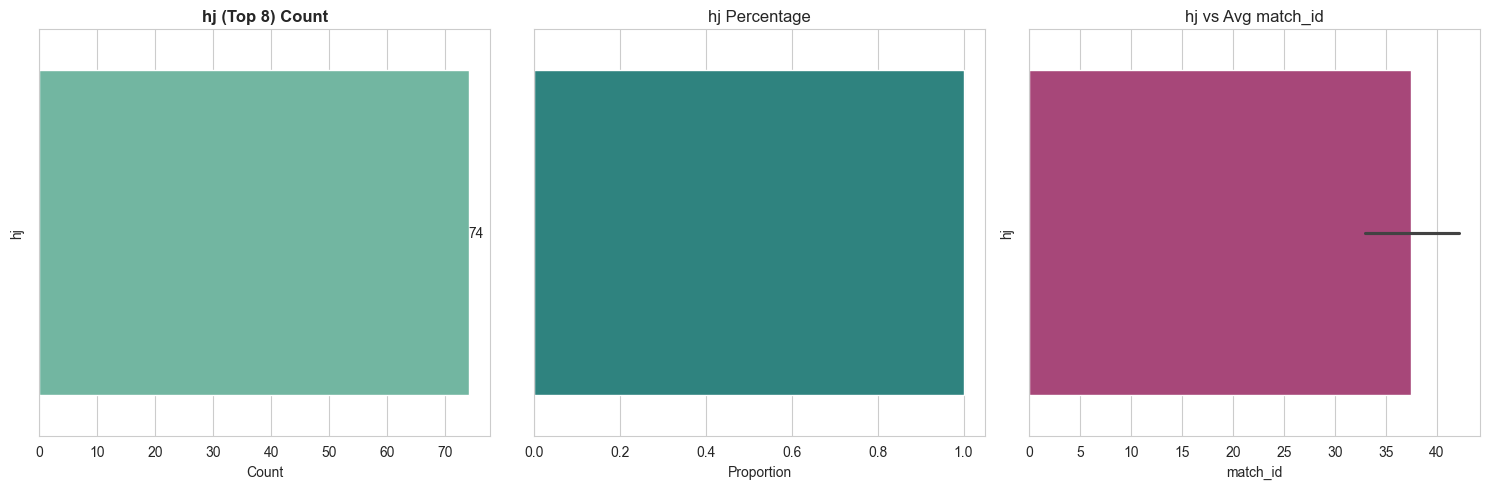

Analyzing Categorical Feature: jk


C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_36016\2961420997.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


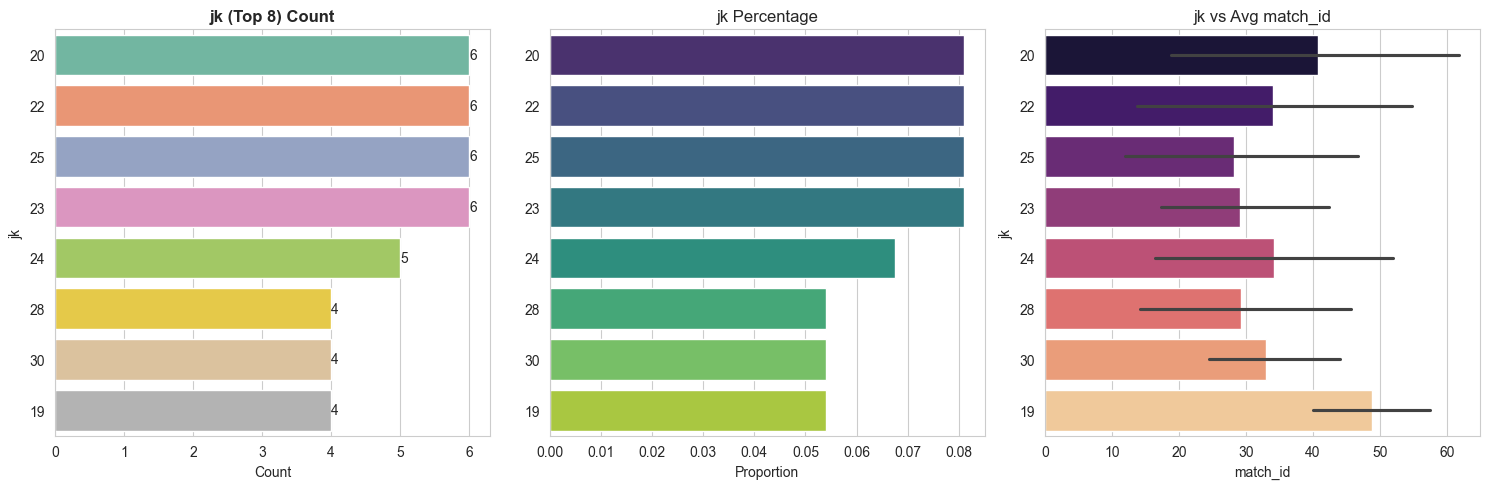

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

def visualize_categorical_features_full(
    df,
    categorical_cols,
    continuous_cols=None,
    discrete_cols=None,
    target=None,
    top_n=8
):
    
    for col in categorical_cols:
        print("="*100)
        print(f"Analyzing Categorical Feature: {col}")
        print("="*100)
        
        
        top_categories = df[col].value_counts().nlargest(top_n).index
        data = df[df[col].isin(top_categories)]
        
       
        n_plots = 2  # count + percentage
        
        if continuous_cols and len(continuous_cols) > 0:
            n_plots += 1
        
        if discrete_cols and len(discrete_cols) > 0:
            n_plots += 1
        
        if target:
            n_plots += 1
        
        fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5))
        
        if n_plots == 1:
            axes = [axes]
        
        plot_idx = 0
        
      
        ax = axes[plot_idx]
        sns.countplot(
            y=col,
            data=data,
            order=top_categories,
            palette="Set2",
            ax=ax
        )
        
        ax.set_title(f"{col} (Top {top_n}) Count", fontweight='bold')
        ax.set_xlabel("Count")
        ax.set_ylabel(col)
        
        for p in ax.patches:
            ax.annotate(
                f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center'
            )
        
        plot_idx += 1
        
       
        ax = axes[plot_idx]
        
        freq = df[col].value_counts(normalize=True).loc[top_categories]
        
        sns.barplot(
            y=freq.index,
            x=freq.values,
            palette="viridis",
            ax=ax
        )
        
        ax.set_title(f"{col} Percentage")
        ax.set_xlabel("Proportion")
        ax.set_ylabel("")
        
        plot_idx += 1
        
    
        if continuous_cols and len(continuous_cols) > 0:
            ax = axes[plot_idx]
            cont = continuous_cols[0]
            
            sns.boxplot(
                y=col,
                x=cont,
                data=data,
                order=top_categories,
                palette="flare",
                ax=ax
            )
            
            ax.set_title(f"{col} vs {cont}")
            plot_idx += 1
        
       
        if discrete_cols and len(discrete_cols) > 0:
            ax = axes[plot_idx]
            disc = discrete_cols[0]
            
            sns.barplot(
                y=col,
                x=disc,
                data=data,
                order=top_categories,
                estimator='mean',
                palette="magma",
                ax=ax
            )
            
            ax.set_title(f"{col} vs Avg {disc}")
            plot_idx += 1
        
       
        if target:
            ax = axes[plot_idx]
            
            if df[target].nunique() <= 10:
                ct = pd.crosstab(data[col], data[target], normalize='index')
                ct.plot(kind='barh', stacked=True, ax=ax, colormap="viridis")
                ax.set_title(f"{col} vs {target}")
                ax.set_xlabel("Proportion")
            else:
                sns.boxplot(
                    y=col,
                    x=target,
                    data=data,
                    order=top_categories,
                    palette="coolwarm",
                    ax=ax
                )
                ax.set_title(f"{col} vs {target}")
        
        plt.tight_layout()
        plt.show()

visualize_categorical_features_full(
    df,
    categorical_cols=categorical_cols,
    continuous_cols=continuous_cols,
    discrete_cols=discrete_cols,
    top_n=8
)